<a href="https://colab.research.google.com/github/mcdelahozr/ram_ia/blob/main/Nuevo_codigo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# After running the above cell and authorizing access, you can read your file.
# Replace 'path/to/your/file.csv' with the actual path to your file in Google Drive.
# For example: '/content/drive/MyDrive/my_folder/my_file.csv'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1. Ubicación Base de Datos, lectura y visualización

In [ ]:
import pandas as pd

# Define the full path to your Excel file in Google Drive
file_path = '/content/drive/MyDrive/BSD_Grebo/BSD_Grebo UCI 2025 adultos.xlsx'

try:
    # Read the Excel file into a pandas DataFrame, specifying header=1 for the second row
    df_adultos = pd.read_excel(file_path, header=1)
    print("Excel file read successfully with header from the second row.")

    # Display the first 5 rows of the DataFrame with correct headers
    display(df_adultos.head(15))
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure the path and file name are correct and that Google Drive is mounted.")
except Exception as e:
    print(f"An error occurred while reading the Excel file: {e}")
    print("Please check the file's integrity and permissions.")

Excel file read successfully with header from the second row.


,País,Laboratorio,Origen,Número de identificación,Apellido,Nombre,Sexo,Fecha de nacimiento,Edad,Categoría de edad,...,Important species,Important resistance,Save the isolate,Send to a reference laboratory,Control de infección,Therapy comment,Other alert,Low frequency,Invalid data,Invalid values
0,COL,SRF,NaN,1014194737,ROJAS,SARA,f,1988-09-20,36.0,adu,...,False,False,False,False,False,False,False,False,False,NaN
1,COL,CLS,NaN,10171377,ECHEVERRY BEDOYA,WILLIAM ALONSO,m,1965-04-18,60.0,adu,...,False,False,False,False,False,False,False,False,False,NaN
2,COL,CLS,NaN,1036338877,PEÑA RODRIGUEZ,LAURA ANDREA,f,1994-11-30,30.0,adu,...,False,False,False,False,False,False,False,False,False,NaN
3,COL,SRF,NaN,1106307044,FORERO,HERNANDO,m,1987-07-13,37.0,adu,...,False,False,False,False,False,False,False,False,False,NaN
4,COL,SRF,NaN,20956466,GARCIA,MARIA FANNY,f,1964-12-15,60.0,adu,...,False,False,False,False,False,False,False,False,False,NaN
5,COL,CLS,NaN,51811394,PEREZ BETANCOURT,ELSA MARIA,f,1966-04-27,59.0,adu,...,False,False,False,False,False,False,False,False,False,NaN
6,COL,COL,NaN,51857355,TERRONT LOZANO,MONICA ALEXANDRA,f,1967-04-26,57.0,adu,...,False,False,False,False,False,False,False,False,False,NaN
7,COL,CLS,NaN,80082585,PIEDRA HERNANDEZ,JOSE MANUEL,m,1979-10-01,46.0,adu,...,False,False,False,False,False,False,False,False,False,NaN
8,COL,FSB,NaN,1057577207,ARAQUE,DIEGO FERNANDO,m,1988-03-17,37.0,adu,...,False,False,False,False,False,False,False,False,False,NaN
9,COL,SCL,h,14275983,QUINTERO,BERTULFO,m,1957-02-12,67.0,adu,...,False,False,False,False,False,False,False,False,False,NaN


2. Análisis Preliminar del Dataframe

Resumen de la información del DataFrame, incluyendo los tipos de datos de cada columna y el conteo de valores no nulos. Esto ayudará a entender qué tipo de datos tenemos y la completitud de cada columna.

In [ ]:
# Muestra información concisa del DataFrame, incluyendo dtypes y valores no nulos
df_adultos.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2346 entries, 0 to 2345
Data columns (total 165 columns):
 #    Column                                   Non-Null Count  Dtype         
---   ------                                   --------------  -----         
 0    País                                     2345 non-null   object        
 1    Laboratorio                              2346 non-null   object        
 2    Origen                                   538 non-null    object        
 3    Número de identificación                 2346 non-null   object        
 4    Apellido                                 2346 non-null   object        
 5    Nombre                                   2346 non-null   object        
 6    Sexo                                     2341 non-null   object        
 7    Fecha de nacimiento                      2341 non-null   datetime64[ns]
 8    Edad                                     2341 non-null   float64       
 9    Categoría de edad           

3. Limpieza: Eliminación de Columnas con Valores Uniformemente Falsos o Completamente Vacíos
Continuamos con la limpieza, eliminando columnas que no aportan información útil para el análisis. Esto incluye columnas donde todos los valores son False (indicando ausencia total de una característica) y columnas donde todos los valores son NaN (completamente vacías).

In [ ]:
import numpy as np

# Identify columns that are entirely NaN
columns_all_nan = df_adultos.columns[df_adultos.isnull().all()].tolist()

# Identify columns where all non-NaN values are False
columns_all_false = []
for col in df_adultos.columns:
    # Check if the column contains any non-NaN values
    if df_adultos[col].count() > 0:
        # Check if all non-NaN values are False
        if (df_adultos[col].dropna() == False).all():
            columns_all_false.append(col)

print(f"Columns with all NaN values: {columns_all_nan}")
print(f"Columns with all non-NaN values as False: {columns_all_false}")

# Combine the lists and remove duplicates
columns_to_consider_for_dropping = list(set(columns_all_nan + columns_all_false))
print(f"\nCombined list of columns to consider for dropping (empty or all False): {columns_to_consider_for_dropping}")
print(f"Number of such columns: {len(columns_to_consider_for_dropping)}")

Columns with all NaN values: ['Número de aislamiento', 'VRE', 'Screening para MRSA', 'Test de Hodge Modificado', 'AMK', 'AMX', 'AMC', 'AMP', 'SAM', 'ATM', 'CEP', 'CZO', 'FEP', 'CSL', 'CTX', 'CTT', 'FOX', 'CAZ', 'CRO', 'CIP', 'CLI', 'CHL', 'ERY', 'FLU', 'GEN', 'IPM', 'LVX', 'LNZ', 'MEM', 'MFX', 'NIT', 'PEN', 'PIP', 'RIF', 'TCY', 'TCC', 'AMX.1', 'CEP.1', 'CTT.1', 'DOR', 'GAT', 'ITR', 'PIP.1', 'POL', 'QDA.1', 'TLT', 'TOB', 'X_2', 'POL.1', 'Priority', 'Organisms', 'Isolate alerts', 'Invalid values']
Columns with all non-NaN values as False: ['VAN.2', 'IPM.2', 'MEM.2', 'FOS.1', 'COL.1', 'TGC.2', 'CAS', 'FMD', 'Alert', 'Quality control', 'Important species', 'Important resistance', 'Save the isolate', 'Send to a reference laboratory', 'Control de infección', 'Therapy comment', 'Other alert', 'Low frequency', 'Invalid data']

Combined list of columns to consider for dropping (empty or all False): ['Low frequency', 'TGC.2', 'ITR', 'MEM.2', 'Control de infección', 'Invalid values', 'CRO', 'Inva

3. Limpieza: Eliminación de Columnas con Valores Uniformemente Falsos o Completamente Vacíos
Continuamos con la limpieza, eliminando columnas que no aportan información útil para el análisis. Esto incluye columnas donde todos los valores son False (indicando ausencia total de una característica) y columnas donde todos los valores son NaN (completamente vacías).

In [ ]:
# Drop the identified columns from the DataFrame
initial_columns_count = df_adultos.shape[1]
df_adultos_cleaned = df_adultos.drop(columns=columns_to_consider_for_dropping)

print(f"Original number of columns: {initial_columns_count}")
print(f"Number of columns dropped: {len(columns_to_consider_for_dropping)}")
print(f"New number of columns: {df_adultos_cleaned.shape[1]}")

# Display the first few rows and information of the cleaned DataFrame to verify
print("\nFirst 5 rows of the cleaned DataFrame:")
display(df_adultos_cleaned.head())

print("\nInfo of the cleaned DataFrame:")
df_adultos_cleaned.info()

Original number of columns: 165
Number of columns dropped: 72
New number of columns: 93

First 5 rows of the cleaned DataFrame:


,País,Laboratorio,Origen,Número de identificación,Apellido,Nombre,Sexo,Fecha de nacimiento,Edad,Categoría de edad,...,TGC.1,SXT.1,VAN.1,VOR,FOS,CAS.1,DAP,CZA,CZT,NOR
0,COL,SRF,NaN,1014194737,ROJAS,SARA,f,1988-09-20,36.0,adu,...,<=1,>2,NaN,NaN,64,NaN,NaN,NaN,NaN,NaN
1,COL,CLS,NaN,10171377,ECHEVERRY BEDOYA,WILLIAM ALONSO,m,1965-04-18,60.0,adu,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,COL,CLS,NaN,1036338877,PEÑA RODRIGUEZ,LAURA ANDREA,f,1994-11-30,30.0,adu,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,COL,SRF,NaN,1106307044,FORERO,HERNANDO,m,1987-07-13,37.0,adu,...,NaN,<=.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<=2
4,COL,SRF,NaN,20956466,GARCIA,MARIA FANNY,f,1964-12-15,60.0,adu,...,<=1,<=1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Info of the cleaned DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2346 entries, 0 to 2345
Data columns (total 93 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   País                                     2345 non-null   object        
 1   Laboratorio                              2346 non-null   object        
 2   Origen                                   538 non-null    object        
 3   Número de identificación                 2346 non-null   object        
 4   Apellido                                 2346 non-null   object        
 5   Nombre                                   2346 non-null   object        
 6   Sexo                                     2341 non-null   object        
 7   Fecha de nacimiento                      2341 non-null   datetime64[ns]
 8   Edad                                     2341 non-null   float64       
 9   Categoría

## 4. Análisis Demográfico

Vamos a realizar un análisis demográfico básico de los datos, centrándonos en las columnas de 'Sexo' y 'Edad' para entender la distribución de la población en nuestro conjunto de datos.

### Análisis de 'Sexo' (Gender) ###
Distribución por Sexo:
 Sexo
m      1323
f      1018
NaN       5
Name: count, dtype: int64


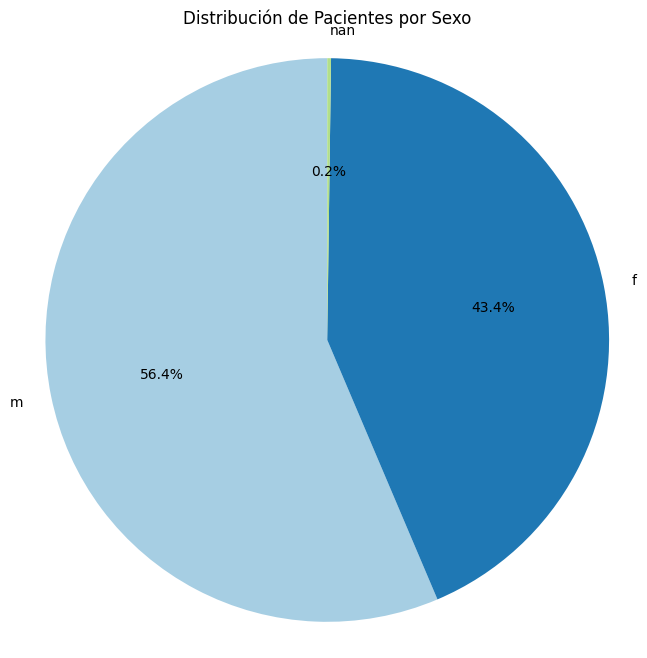

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("### Análisis de 'Sexo' (Gender) ###")
sex_distribution = df_adultos_cleaned['Sexo'].value_counts(dropna=False)
print("Distribución por Sexo:\n", sex_distribution)

plt.figure(figsize=(8, 8))
plt.pie(sex_distribution.values, labels=sex_distribution.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Paired'))
plt.title('Distribución de Pacientes por Sexo')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


### Análisis de 'Edad' (Age) ###
Estadísticas Descriptivas para Edad:
 count    2341.000000
mean       61.627937
std        18.686058
min        17.000000
25%        50.000000
50%        65.000000
75%        76.000000
max        98.000000
Name: Edad, dtype: float64


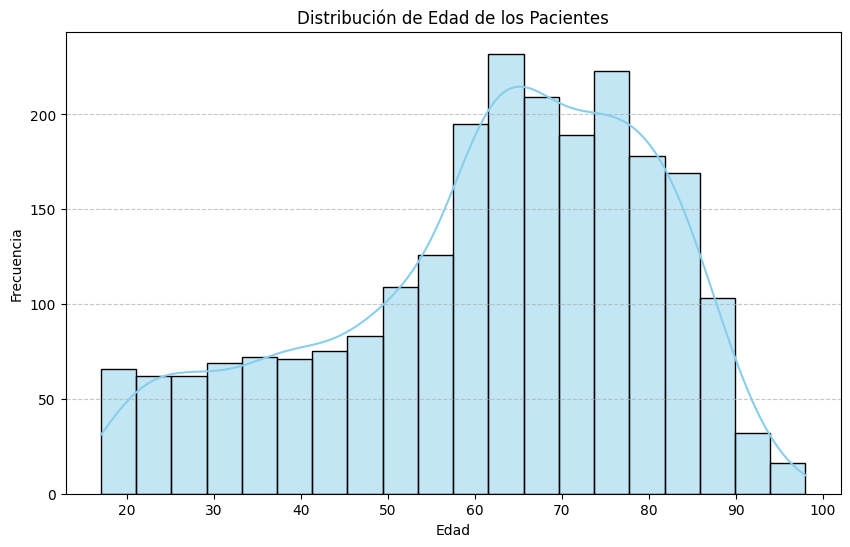

In [ ]:
print("\n### Análisis de 'Edad' (Age) ###")
print("Estadísticas Descriptivas para Edad:\n", df_adultos_cleaned['Edad'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(df_adultos_cleaned['Edad'].dropna(), bins=20, kde=True, color='skyblue')
plt.title('Distribución de Edad de los Pacientes')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### Análisis de 'Categoría de edad' (Age Category) ###
Distribución por Categoría de Edad:
 Categoría de edad
adu    2341
-         4
NaN       1
Name: count, dtype: int64


/tmp/ipykernel_2205/1004721128.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_category_distribution.index, y=age_category_distribution.values, palette='magma')


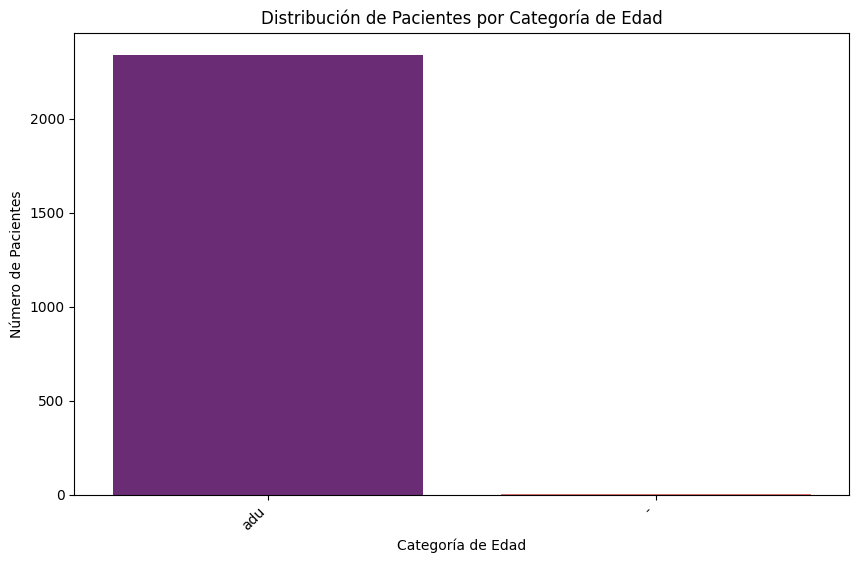

In [ ]:
print("\n### Análisis de 'Categoría de edad' (Age Category) ###")
age_category_distribution = df_adultos_cleaned['Categoría de edad'].value_counts(dropna=False)
print("Distribución por Categoría de Edad:\n", age_category_distribution)

plt.figure(figsize=(10, 6))
sns.barplot(x=age_category_distribution.index, y=age_category_distribution.values, palette='magma')
plt.title('Distribución de Pacientes por Categoría de Edad')
plt.xlabel('Categoría de Edad')
plt.ylabel('Número de Pacientes')
plt.xticks(rotation=45, ha='right')
plt.show()

### 5. Cruce entre 'Sexo' y 'Categoría de Edad'

Vamos a analizar la relación entre el sexo y la categoría de edad de los pacientes utilizando una tabla de contingencia y una visualización.

Tabla de contingencia (Sexo vs. Categoría de Edad):



Categoría de edad,-,adu,NaN
Sexo,,,
f,0,1018,0
m,0,1323,0
NaN,4,0,1


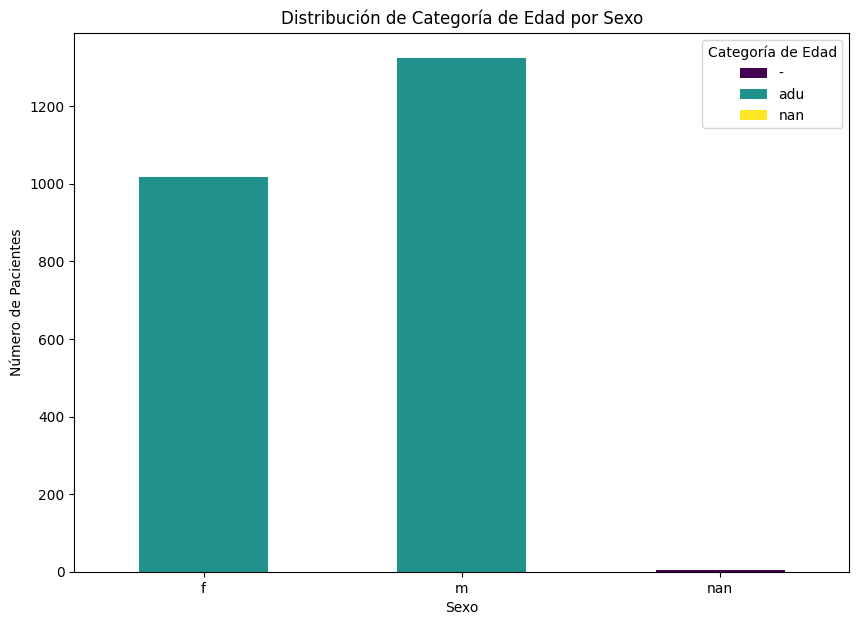

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Crear una tabla de contingencia entre 'Sexo' y 'Categoría de edad'
crosstab_sex_age_category = pd.crosstab(df_adultos_cleaned['Sexo'], df_adultos_cleaned['Categoría de edad'], dropna=False)
print("Tabla de contingencia (Sexo vs. Categoría de Edad):\n")
display(crosstab_sex_age_category)

# Visualizar la relación con un gráfico de barras apiladas
crosstab_sex_age_category.plot(kind='bar', stacked=True, figsize=(10, 7), colormap='viridis')
plt.title('Distribución de Categoría de Edad por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Número de Pacientes')
plt.xticks(rotation=0)
plt.legend(title='Categoría de Edad')
plt.show()

Nueva distribución por Categoría de Edad después de la limpieza:



,count
Categoría de edad,
adu,2341
Desconocido,5


/tmp/ipykernel_2205/3138020714.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cleaned_age_category_distribution.index, y=cleaned_age_category_distribution.values, palette='magma')


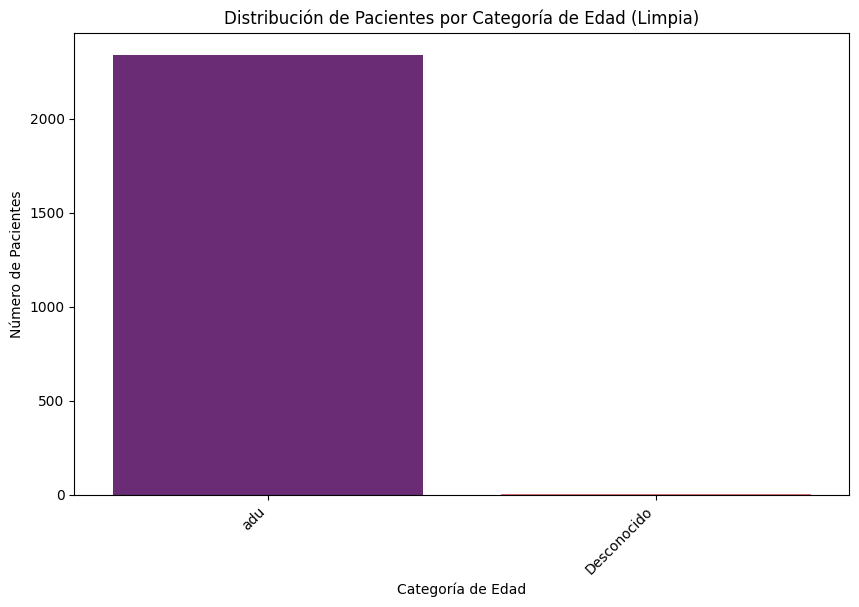

In [ ]:
# Reemplazar '-' y NaN en 'Categoría de edad' por 'Desconocido'
df_adultos_cleaned['Categoría de edad'] = df_adultos_cleaned['Categoría de edad'].replace('-', 'Desconocido')
df_adultos_cleaned['Categoría de edad'] = df_adultos_cleaned['Categoría de edad'].fillna('Desconocido')

print("Nueva distribución por Categoría de Edad después de la limpieza:\n")
cleaned_age_category_distribution = df_adultos_cleaned['Categoría de edad'].value_counts(dropna=False)
display(cleaned_age_category_distribution)

# Opcional: Visualizar la nueva distribución
plt.figure(figsize=(10, 6))
sns.barplot(x=cleaned_age_category_distribution.index, y=cleaned_age_category_distribution.values, palette='magma')
plt.title('Distribución de Pacientes por Categoría de Edad (Limpia)')
plt.xlabel('Categoría de Edad')
plt.ylabel('Número de Pacientes')
plt.xticks(rotation=45, ha='right')
plt.show()

6. Distribución de muestras por Institución

/tmp/ipykernel_2205/3805917342.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_adultos_cleaned, y='Laboratorio', order=df_adultos_cleaned['Laboratorio'].value_counts().index, palette='viridis')


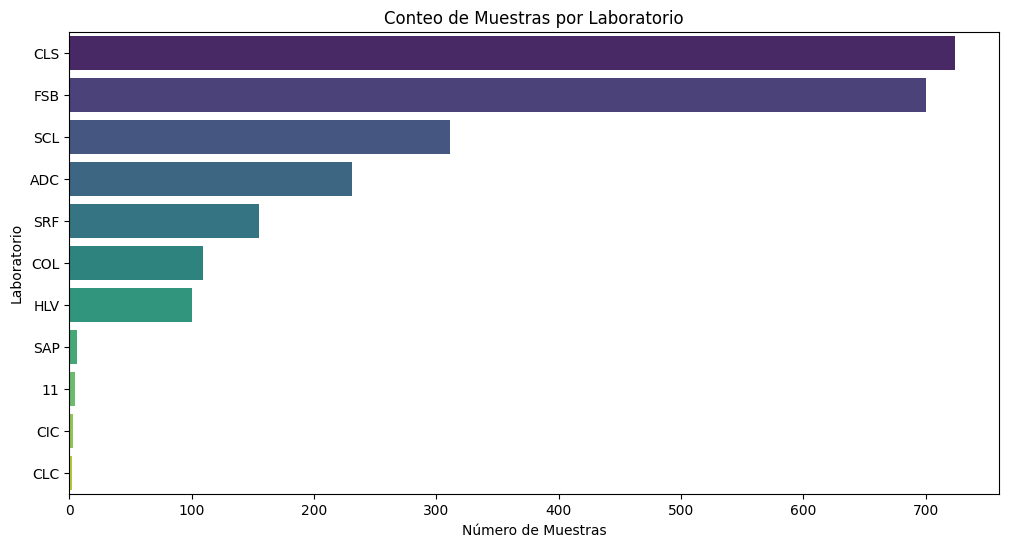

/tmp/ipykernel_2205/3805917342.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_adultos_cleaned, y='Institución', order=df_adultos_cleaned['Institución'].value_counts().index, palette='magma')


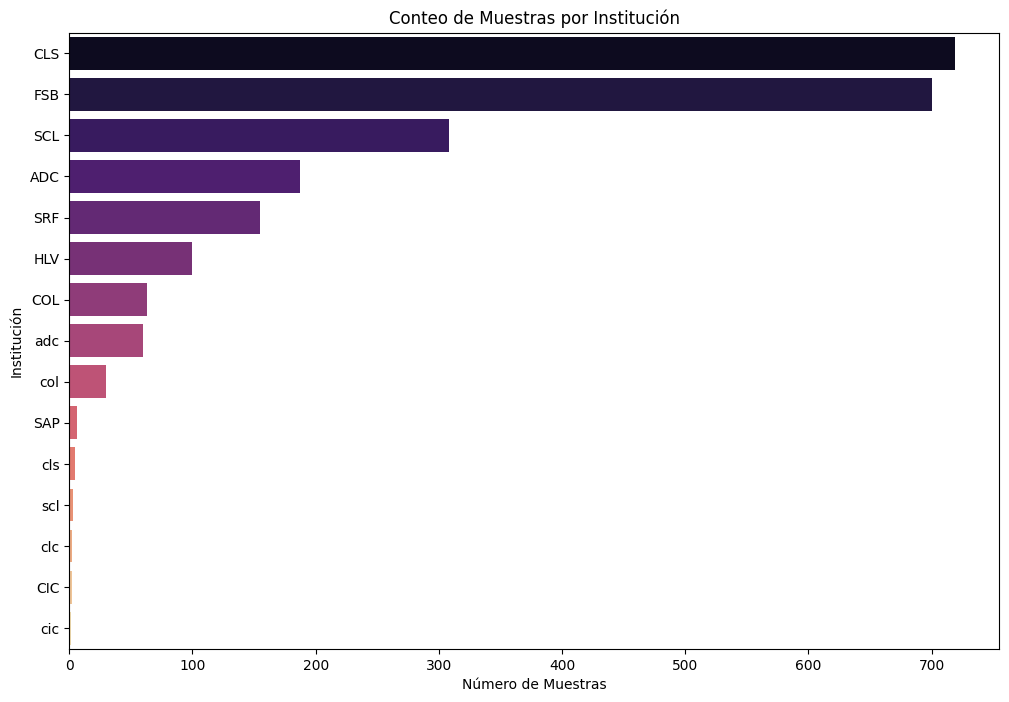

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_adultos_cleaned, y='Laboratorio', order=df_adultos_cleaned['Laboratorio'].value_counts().index, palette='viridis')
plt.title('Conteo de Muestras por Laboratorio')
plt.xlabel('Número de Muestras')
plt.ylabel('Laboratorio')
plt.show()


plt.figure(figsize=(12, 8))
sns.countplot(data=df_adultos_cleaned, y='Institución', order=df_adultos_cleaned['Institución'].value_counts().index, palette='magma')
plt.title('Conteo de Muestras por Institución')
plt.xlabel('Número de Muestras')
plt.ylabel('Institución')
plt.show()


7. Análisis Microbiológico

Top 10 Microorganismos más frecuentes (con nombres completos mapeados):



,0
Microorganismo,
Klebsiella pneumoniae ssp pneumoniae,363
Escherichia coli,355
Staphylococcus aureus,254
Candida albicans,177
Pseudomonas aeruginosa,106
Staphylococcus epidermidis,104
Enterococcus faecalis,104
Proteus mirabilis,72
Klebsiella oxytoca,53


/tmp/ipykernel_2205/3301603119.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=microorganismo_counts.head(10).values, y=top_microorganismos_full_names, palette='crest')


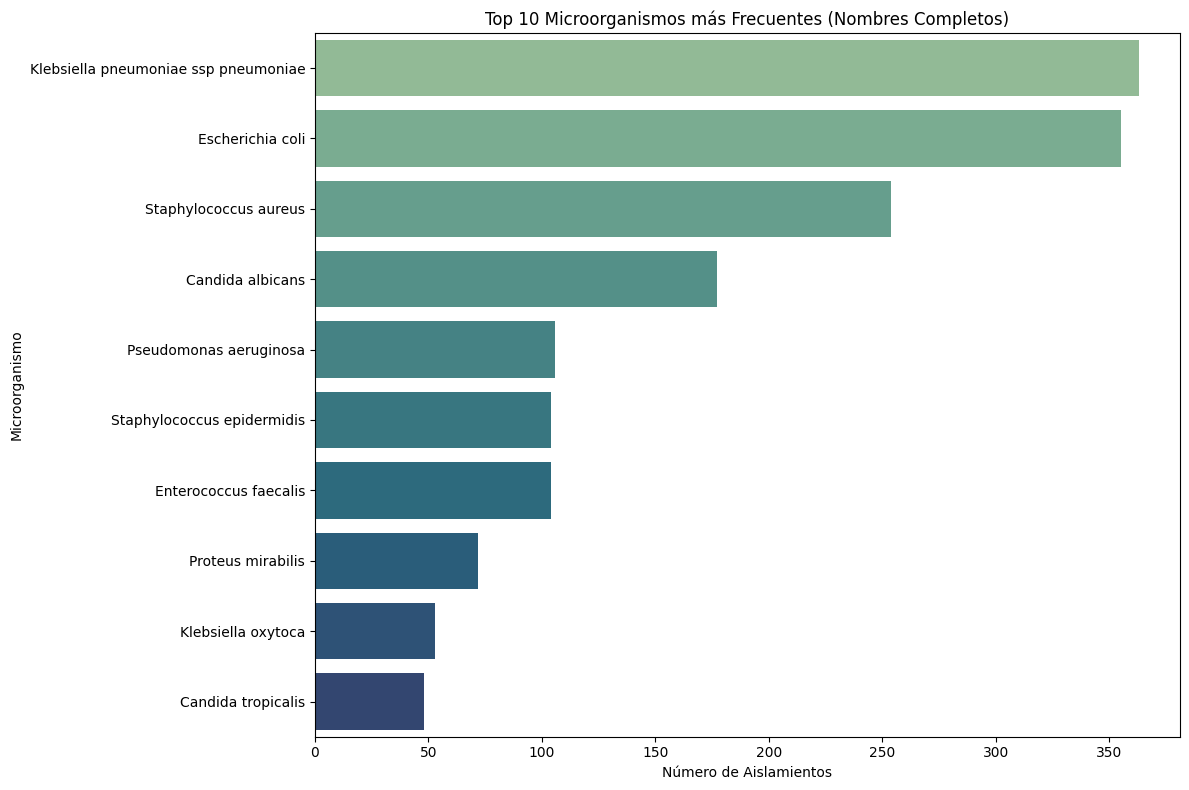

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a mapping from 'Microorganismo' (abbreviation) to 'Código de microorganismo local' (full name)
# We'll use drop_duplicates to ensure unique mappings if there are multiple entries for the same abbreviation
# and then set 'Microorganismo' as index to create a Series for mapping.
microorganism_name_map = df_adultos_cleaned.dropna(subset=['Microorganismo', 'Código de microorganismo local']).drop_duplicates(subset=['Microorganismo']).set_index('Microorganismo')['Código de microorganismo local']

# Contar la frecuencia de cada microorganismo usando la columna 'Microorganismo'
microorganismo_counts = df_adultos_cleaned['Microorganismo'].value_counts(dropna=False)

# Get the top 10 microorganisms by their abbreviated codes
top_10_abbreviations = microorganismo_counts.head(10).index

# Apply the mapping to the indices of the counts to get the full names
mapped_names_series = top_10_abbreviations.map(microorganism_name_map)
# If a full name is not found for an abbreviation, fall back to the abbreviation itself using .where()
top_microorganismos_full_names = mapped_names_series.where(mapped_names_series.notna(), top_10_abbreviations)

print("Top 10 Microorganismos más frecuentes (con nombres completos mapeados):\n")
# Display the counts with the full names as index
display(pd.Series(microorganismo_counts.head(10).values, index=top_microorganismos_full_names))

# Visualizar la distribución de los 10 microorganismos más frecuentes
plt.figure(figsize=(12, 8))
sns.barplot(x=microorganismo_counts.head(10).values, y=top_microorganismos_full_names, palette='crest')
plt.title('Top 10 Microorganismos más Frecuentes (Nombres Completos)')
plt.xlabel('Número de Aislamientos')
plt.ylabel('Microorganismo')
plt.tight_layout()
plt.show()

8. Análisis de Tendencias Temporales de Microorganismos

## 8. Análisis de Tendencias Temporales de Microorganismos

Para entender cómo la presencia de los microorganismos ha variado con el tiempo, analizaremos las tendencias temporales de los microorganismos más frecuentes. Para ello, agruparemos los datos por mes y año, y visualizaremos la frecuencia de los 10 microorganismos más comunes.

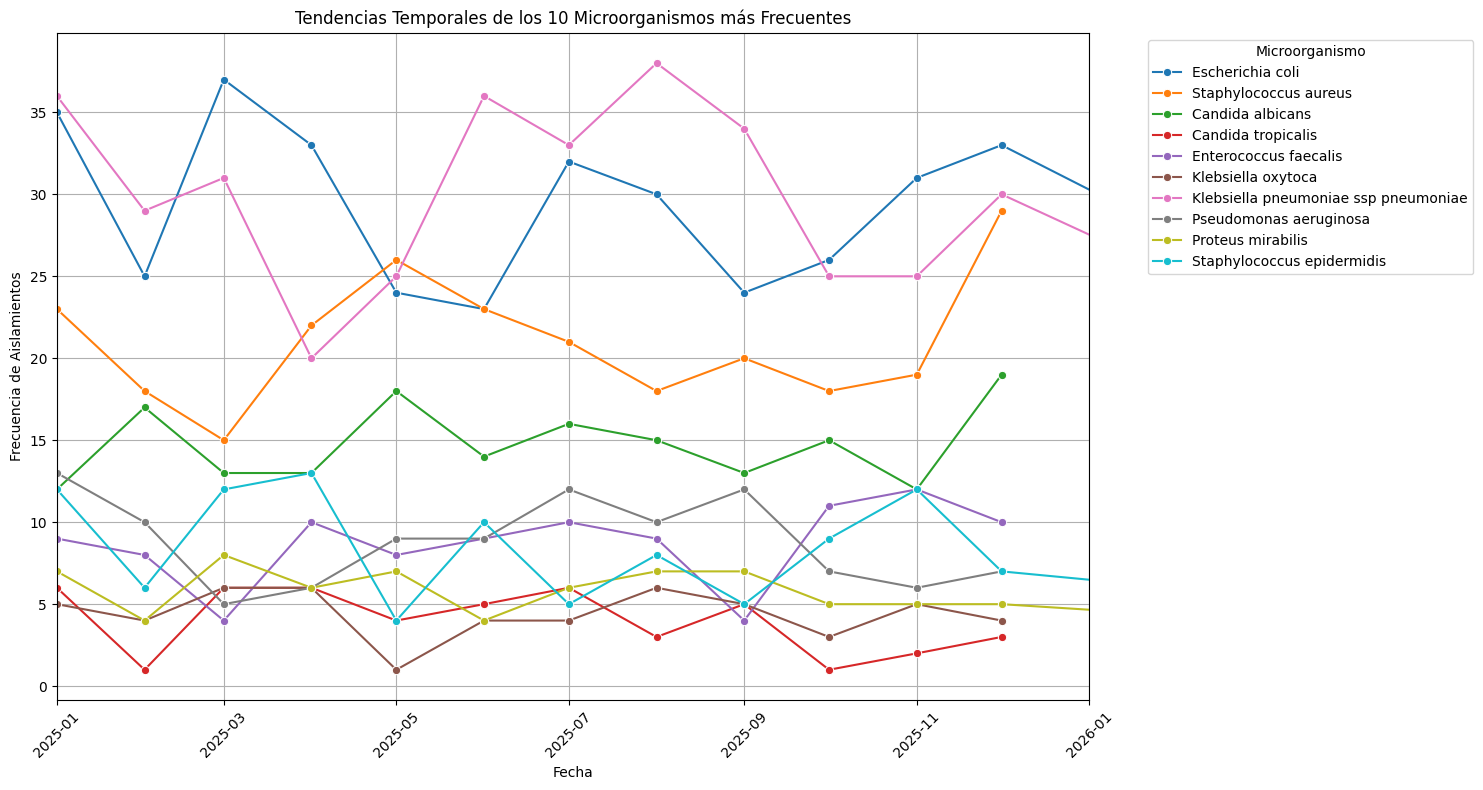

In [ ]:
# Asegurarse de que 'Fecha de muestra' sea tipo datetime
df_adultos_cleaned['Fecha de muestra'] = pd.to_datetime(df_adultos_cleaned['Fecha de muestra'])

# Extraer el año y el mes de la fecha de la muestra
df_adultos_cleaned['Año'] = df_adultos_cleaned['Fecha de muestra'].dt.year
df_adultos_cleaned['Mes'] = df_adultos_cleaned['Fecha de muestra'].dt.month

# Obtener los 10 microorganismos más frecuentes (ya calculados previamente en 'microorganismo_counts')
top_10_microorganismos = microorganismo_counts.head(10).index.tolist()

# Filtrar el DataFrame para incluir solo los 10 microorganismos más frecuentes
df_top_microorganisms = df_adultos_cleaned[df_adultos_cleaned['Microorganismo'].isin(top_10_microorganismos)].copy()

# Agrupar por año, mes y microorganismo, y contar la frecuencia
temporal_trends = df_top_microorganisms.groupby(['Año', 'Mes', 'Microorganismo']).size().reset_index(name='Frecuencia')

# Crear una columna de fecha para el eje x del gráfico
# Convert 'Año' and 'Mes' to int before converting to string to remove '.0'
temporal_trends['Fecha'] = pd.to_datetime(temporal_trends['Año'].astype(int).astype(str) + '-' + temporal_trends['Mes'].astype(int).astype(str) + '-01')

# Mapear los nombres abreviados a los nombres completos para la leyenda
temporal_trends['Microorganismo_Full_Name'] = temporal_trends['Microorganismo'].map(microorganism_name_map).fillna(temporal_trends['Microorganismo'])

# Visualizar las tendencias temporales
plt.figure(figsize=(15, 8))
sns.lineplot(data=temporal_trends, x='Fecha', y='Frecuencia', hue='Microorganismo_Full_Name', marker='o')
plt.title('Tendencias Temporales de los 10 Microorganismos más Frecuentes')
plt.xlabel('Fecha')
plt.ylabel('Frecuencia de Aislamientos')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='Microorganismo', bbox_to_anchor=(1.05, 1), loc='upper left')
# Set x-axis limits to the requested range (from 2025-01 to 2026-01)
plt.xlim(pd.to_datetime('2025-01-01'), pd.to_datetime('2026-01-01'))
plt.tight_layout()
plt.show()

## 9. Análisis Comparativo de Frecuencia por Sexo para Microorganismos

Realizaremos un análisis comparativo para ver la distribución de los 10 microorganismos más frecuentes entre los sexos (masculino y femenino).

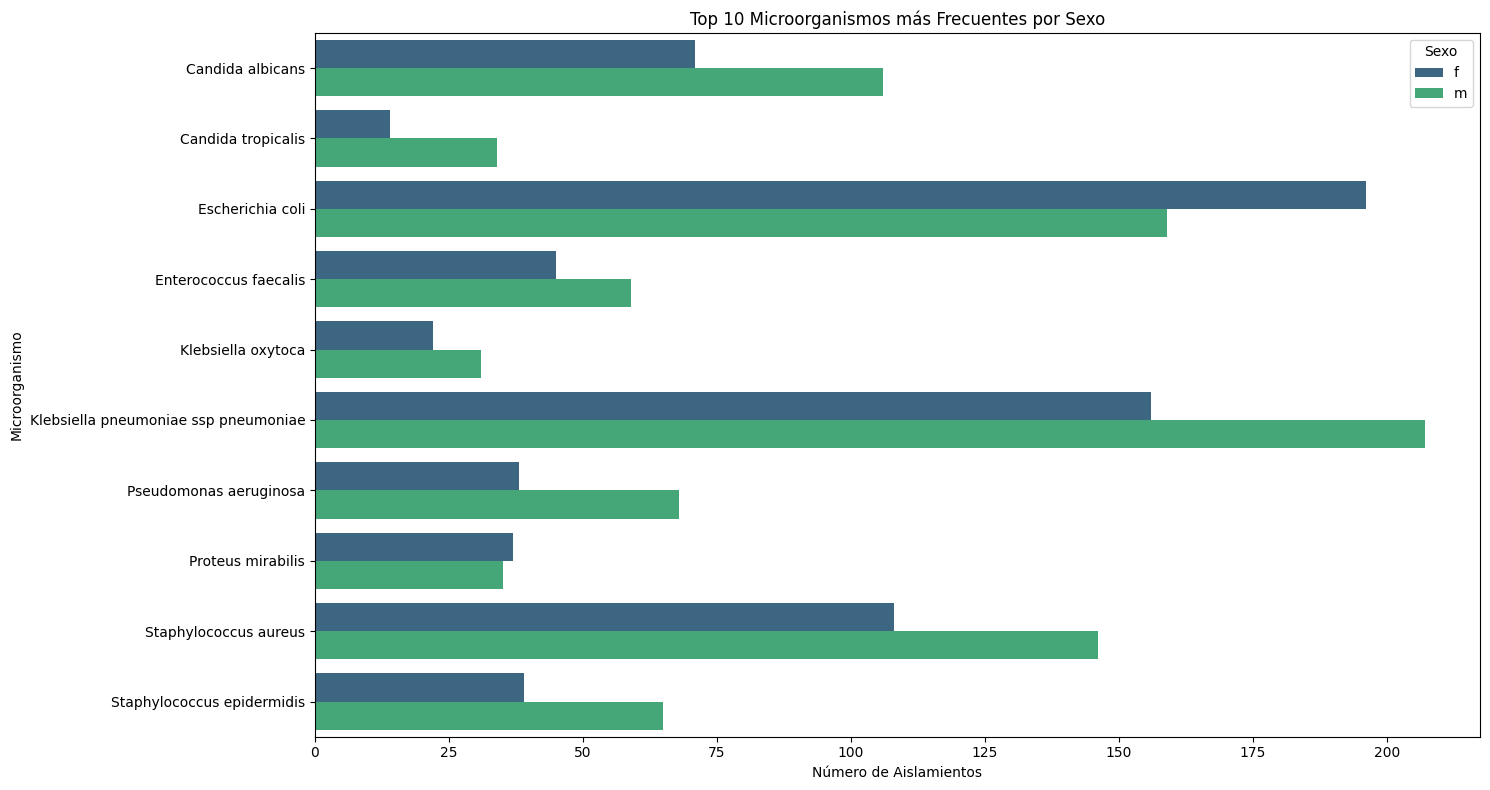

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filtrar el DataFrame para incluir solo los 10 microorganismos más frecuentes
df_sex_microorganism = df_adultos_cleaned[df_adultos_cleaned['Microorganismo'].isin(top_10_microorganismos)].copy()

# Eliminar filas con valores NaN en 'Sexo' si queremos comparar solo M/F
df_sex_microorganism.dropna(subset=['Sexo'], inplace=True)

# Agrupar por sexo y microorganismo, y contar la frecuencia
sex_microorganism_counts = df_sex_microorganism.groupby(['Sexo', 'Microorganismo']).size().reset_index(name='Frecuencia')

# Mapear los nombres abreviados de los microorganismos a nombres completos para la visualización
sex_microorganism_counts['Microorganismo_Full_Name'] = sex_microorganism_counts['Microorganismo'].map(microorganism_name_map).fillna(sex_microorganism_counts['Microorganismo'])

# Visualizar la distribución de los 10 microorganismos más frecuentes por sexo
plt.figure(figsize=(15, 8))
sns.barplot(data=sex_microorganism_counts, x='Frecuencia', y='Microorganismo_Full_Name', hue='Sexo', palette='viridis')
plt.title('Top 10 Microorganismos más Frecuentes por Sexo')
plt.xlabel('Número de Aislamientos')
plt.ylabel('Microorganismo')
plt.legend(title='Sexo')
plt.tight_layout()
plt.show()

## 10. Microorganismos más Frecuentes en Mujeres y Hombres Mayores de 50 Años

Ahora, realizaremos un análisis más específico, centrándonos en los 10 microorganismos más frecuentes para mujeres y hombres mayores de 50 años.


### Microorganismos más Frecuentes en Mujeres > 50 Años ###


,0
Microorganismo,
Escherichia coli,159
Klebsiella pneumoniae ssp pneumoniae,114
Staphylococcus aureus,78
Candida albicans,54
Enterococcus faecalis,32
Staphylococcus epidermidis,31
Pseudomonas aeruginosa,30
Proteus mirabilis,29
strfac,16


/tmp/ipykernel_2205/947706029.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=microorganismo_counts_females.head(10).values, y=top_microorganismos_full_names_females, palette='crest')


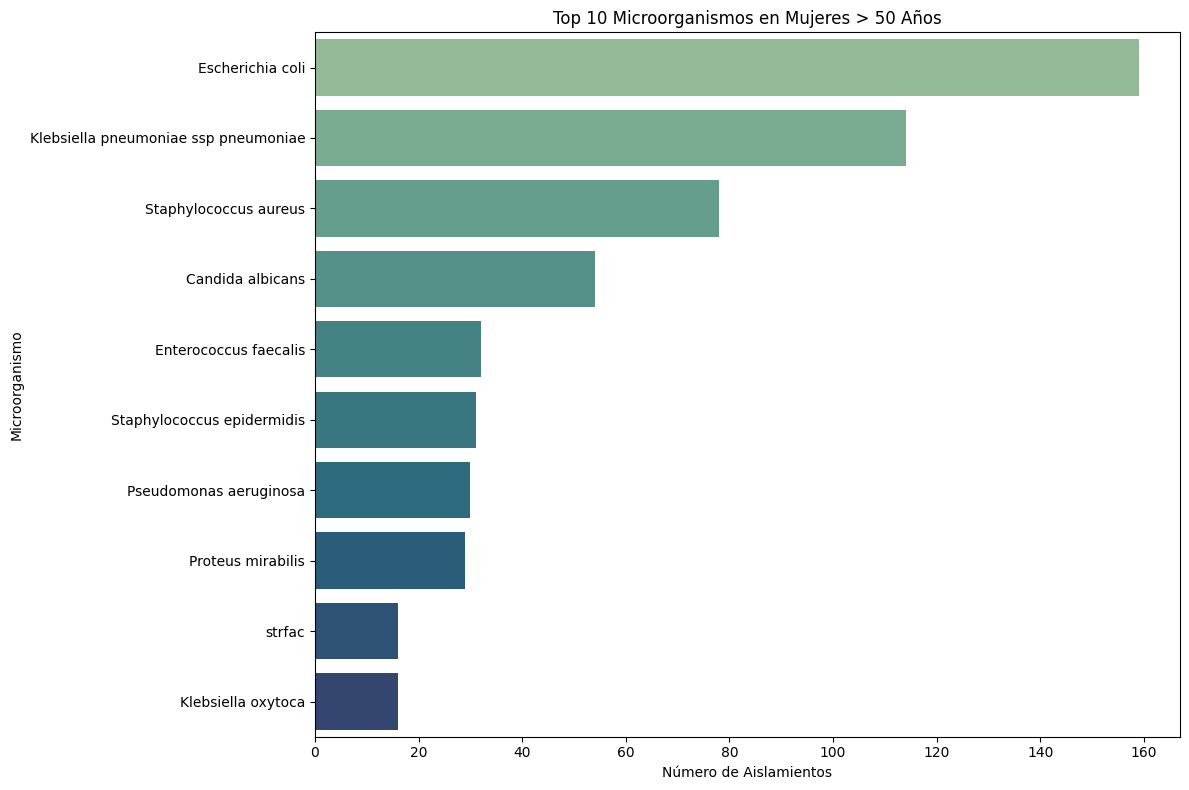


### Microorganismos más Frecuentes en Hombres > 50 Años ###


,0
Microorganismo,
Klebsiella pneumoniae ssp pneumoniae,152
Escherichia coli,126
Staphylococcus aureus,97
Candida albicans,80
Pseudomonas aeruginosa,48
Enterococcus faecalis,44
Staphylococcus epidermidis,41
Proteus mirabilis,31
Klebsiella oxytoca,28


/tmp/ipykernel_2205/947706029.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=microorganismo_counts_males.head(10).values, y=top_microorganismos_full_names_males, palette='crest')


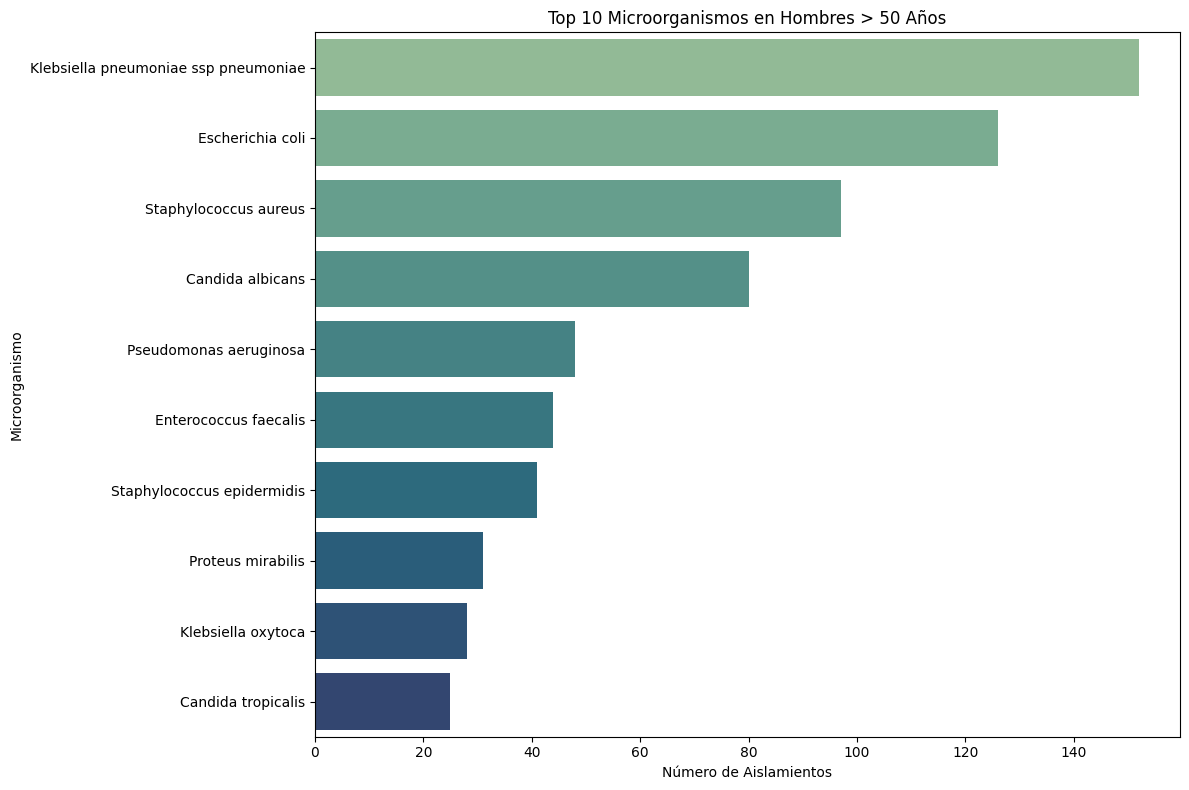

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filtrar el DataFrame para personas mayores de 50 años
df_over_50 = df_adultos_cleaned[df_adultos_cleaned['Edad'] > 50].copy()

# --- Análisis para Mujeres mayores de 50 años ---
print("\n### Microorganismos más Frecuentes en Mujeres > 50 Años ###")
df_females_over_50 = df_over_50[df_over_50['Sexo'] == 'f'].copy()
microorganismo_counts_females = df_females_over_50['Microorganismo'].value_counts(dropna=False)

top_10_abbreviations_females = microorganismo_counts_females.head(10).index
mapped_names_series_females = top_10_abbreviations_females.map(microorganism_name_map)
top_microorganismos_full_names_females = mapped_names_series_females.where(mapped_names_series_females.notna(), top_10_abbreviations_females)

display(pd.Series(microorganismo_counts_females.head(10).values, index=top_microorganismos_full_names_females))

plt.figure(figsize=(12, 8))
sns.barplot(x=microorganismo_counts_females.head(10).values, y=top_microorganismos_full_names_females, palette='crest')
plt.title('Top 10 Microorganismos en Mujeres > 50 Años')
plt.xlabel('Número de Aislamientos')
plt.ylabel('Microorganismo')
plt.tight_layout()
plt.show()

# --- Análisis para Hombres mayores de 50 años ---
print("\n### Microorganismos más Frecuentes en Hombres > 50 Años ###")
df_males_over_50 = df_over_50[df_over_50['Sexo'] == 'm'].copy()
microorganismo_counts_males = df_males_over_50['Microorganismo'].value_counts(dropna=False)

top_10_abbreviations_males = microorganismo_counts_males.head(10).index
mapped_names_series_males = top_10_abbreviations_males.map(microorganism_name_map)
top_microorganismos_full_names_males = mapped_names_series_males.where(mapped_names_series_males.notna(), top_10_abbreviations_males)

display(pd.Series(microorganismo_counts_males.head(10).values, index=top_microorganismos_full_names_males))

plt.figure(figsize=(12, 8))
sns.barplot(x=microorganismo_counts_males.head(10).values, y=top_microorganismos_full_names_males, palette='crest')
plt.title('Top 10 Microorganismos en Hombres > 50 Años')
plt.xlabel('Número de Aislamientos')
plt.ylabel('Microorganismo')
plt.tight_layout()
plt.show()

## 11. Análisis de Microorganismos por Localización (General)

Ahora, realizaremos un análisis de la distribución de los microorganismos más frecuentes por localización, sin aplicar el filtro de edad.


### Top Microorganismos en Localización: uci ad (General) ###


,0
Microorganismo,
Klebsiella pneumoniae ssp pneumoniae,335
Escherichia coli,330
Staphylococcus aureus,241
Candida albicans,170
Pseudomonas aeruginosa,102
Enterococcus faecalis,99
Staphylococcus epidermidis,93
Proteus mirabilis,61
Klebsiella oxytoca,51


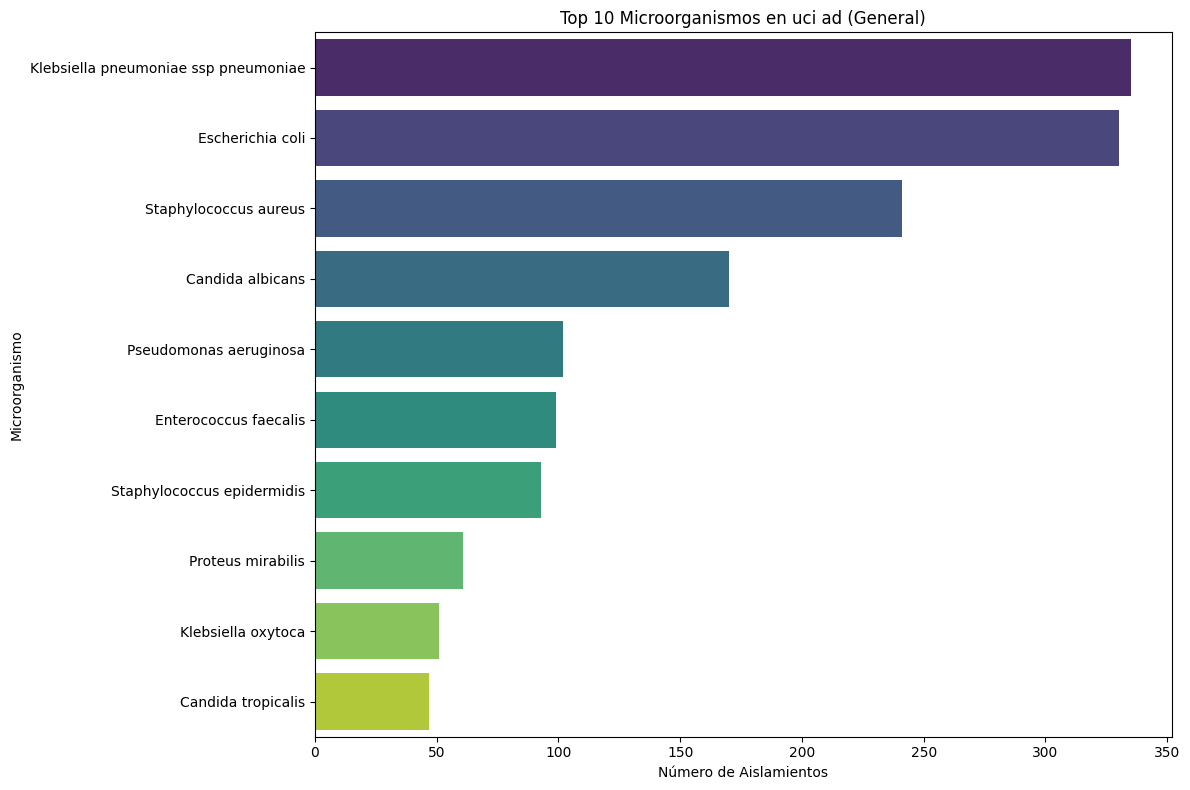


### Top Microorganismos en Localización: uci cv (General) ###


,0
Microorganismo,
Klebsiella pneumoniae ssp pneumoniae,27
Escherichia coli,25
Staphylococcus aureus,13
Proteus mirabilis,11
Staphylococcus epidermidis,11
Candida albicans,7
Enterococcus faecalis,5
Pseudomonas aeruginosa,4
strfac,3


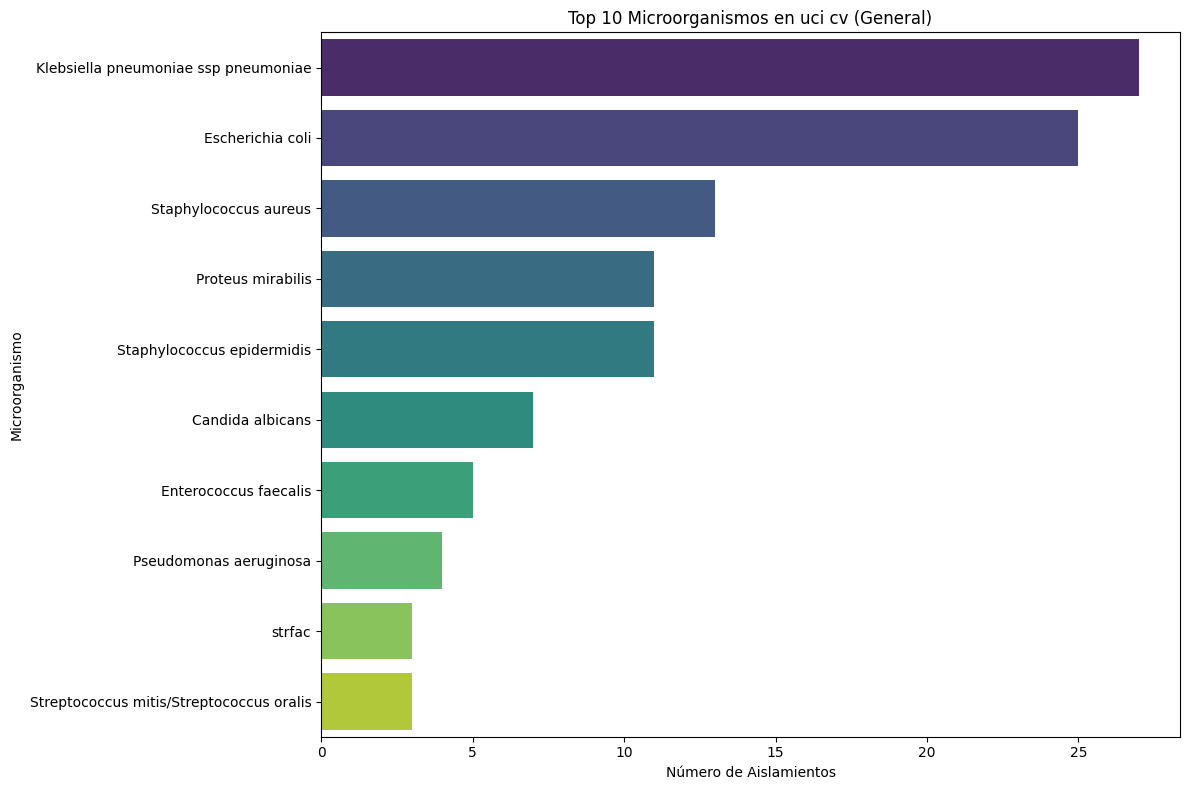


### Top Microorganismos en Localización: Desconocido (General) ###


,0
Microorganismo,
NaN,5


/tmp/ipykernel_2205/1783688911.py:38: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.barplot(data=plot_data,


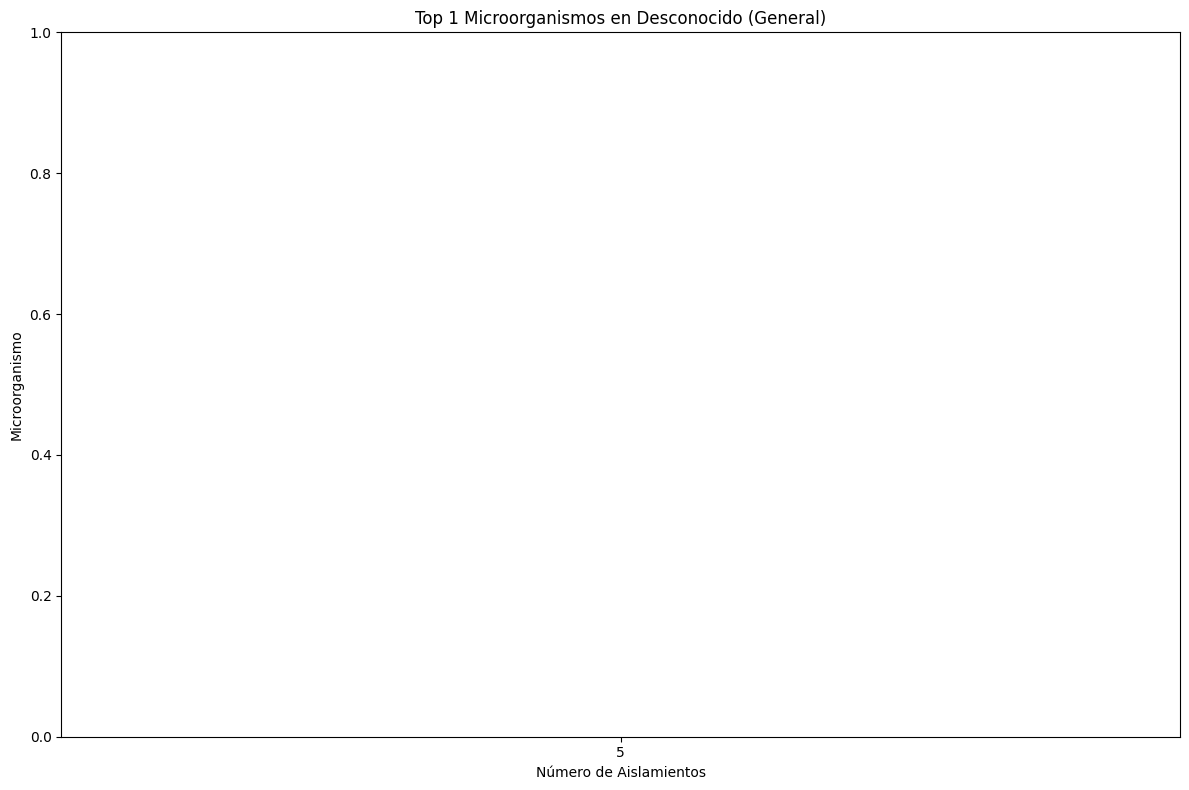


### Top Microorganismos en Localización: ucipe (General) ###


,0
Microorganismo,
Klebsiella pneumoniae ssp pneumoniae,1


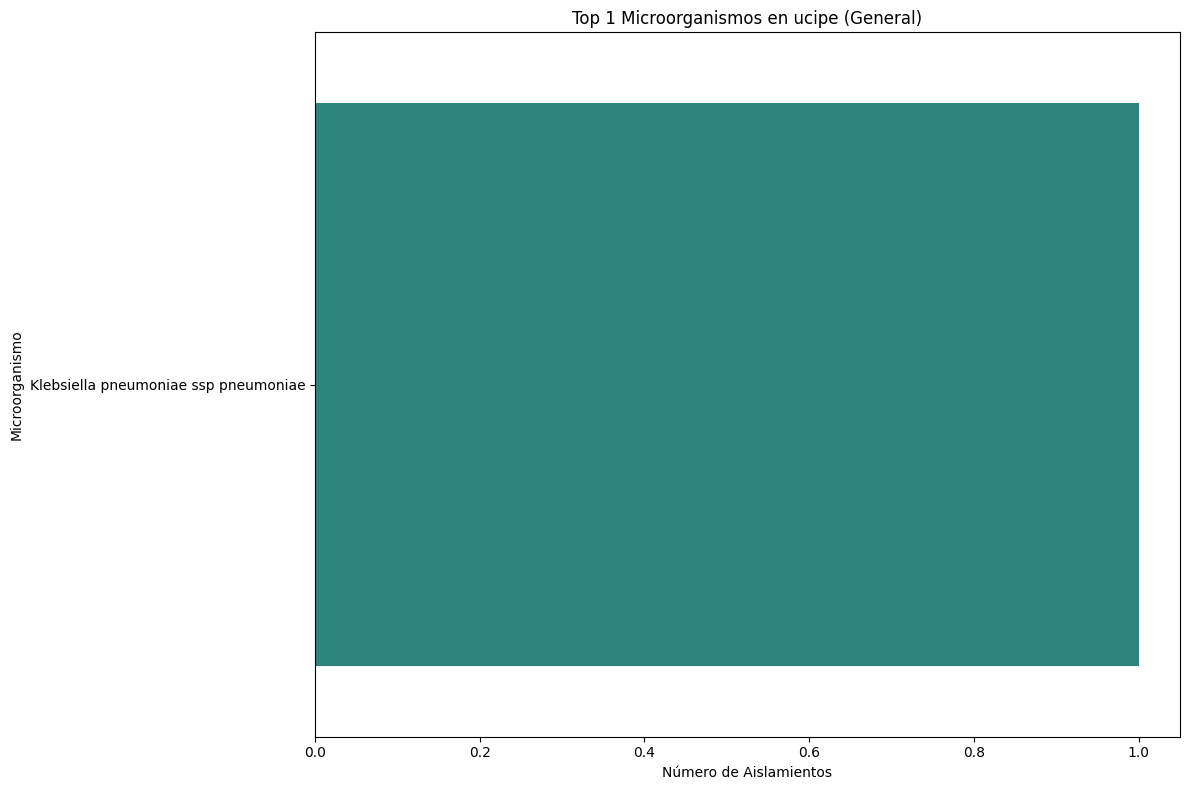

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Handle NaN values in the 'Localización' column for clean grouping
df_adultos_cleaned['Localización'] = df_adultos_cleaned['Localización'].fillna('Desconocido')

# Get unique locations to iterate through
unique_locations_general = df_adultos_cleaned['Localización'].unique()

for location in unique_locations_general:
    print(f"\n### Top Microorganismos en Localización: {location} (General) ###")

    # Filter data for the current location
    df_location_specific_general = df_adultos_cleaned[df_adultos_cleaned['Localización'] == location].copy()

    # Contar la frecuencia de microorganismos en esta localización
    microorganismo_counts_location_general = df_location_specific_general['Microorganismo'].value_counts(dropna=False)

    # Get the top 10 microorganisms (or fewer if there aren't 10)
    top_microorganismos_abbreviations_location_general = microorganismo_counts_location_general.head(10).index

    # Map abbreviated names to full names for visualization
    mapped_names_series_location_general = top_microorganismos_abbreviations_location_general.map(microorganism_name_map)
    top_microorganismos_full_names_location_general = mapped_names_series_location_general.where(mapped_names_series_location_general.notna(), top_microorganismos_abbreviations_location_general)

    # Display the frequency table
    display(pd.Series(microorganismo_counts_location_general.head(10).values, index=top_microorganismos_full_names_location_general))

    # Prepare data for barplot to properly use hue
    plot_data = pd.DataFrame({
        'Frecuencia': microorganismo_counts_location_general.head(10).values,
        'Microorganismo_Full_Name': top_microorganismos_full_names_location_general
    })

    # Visualize the distribution
    plt.figure(figsize=(12, 8))
    sns.barplot(data=plot_data,
                x='Frecuencia',
                y='Microorganismo_Full_Name',
                hue='Microorganismo_Full_Name', # Assign y variable to hue
                palette='viridis',
                legend=False) # Set legend=False as recommended to avoid redundant legend
    plt.title(f'Top {len(top_microorganismos_full_names_location_general)} Microorganismos en {location} (General)')
    plt.xlabel('Número de Aislamientos')
    plt.ylabel('Microorganismo')
    plt.tight_layout()
    plt.show()

## 12. Distribución Unificada de Microorganismos por Localización (UCI ad, Ucipe, UCI cv)

Vamos a generar una visualización unificada para comparar la distribución de los microorganismos más frecuentes en las localizaciones 'uci ad', 'ucipe' y 'uci cv' en un solo gráfico.

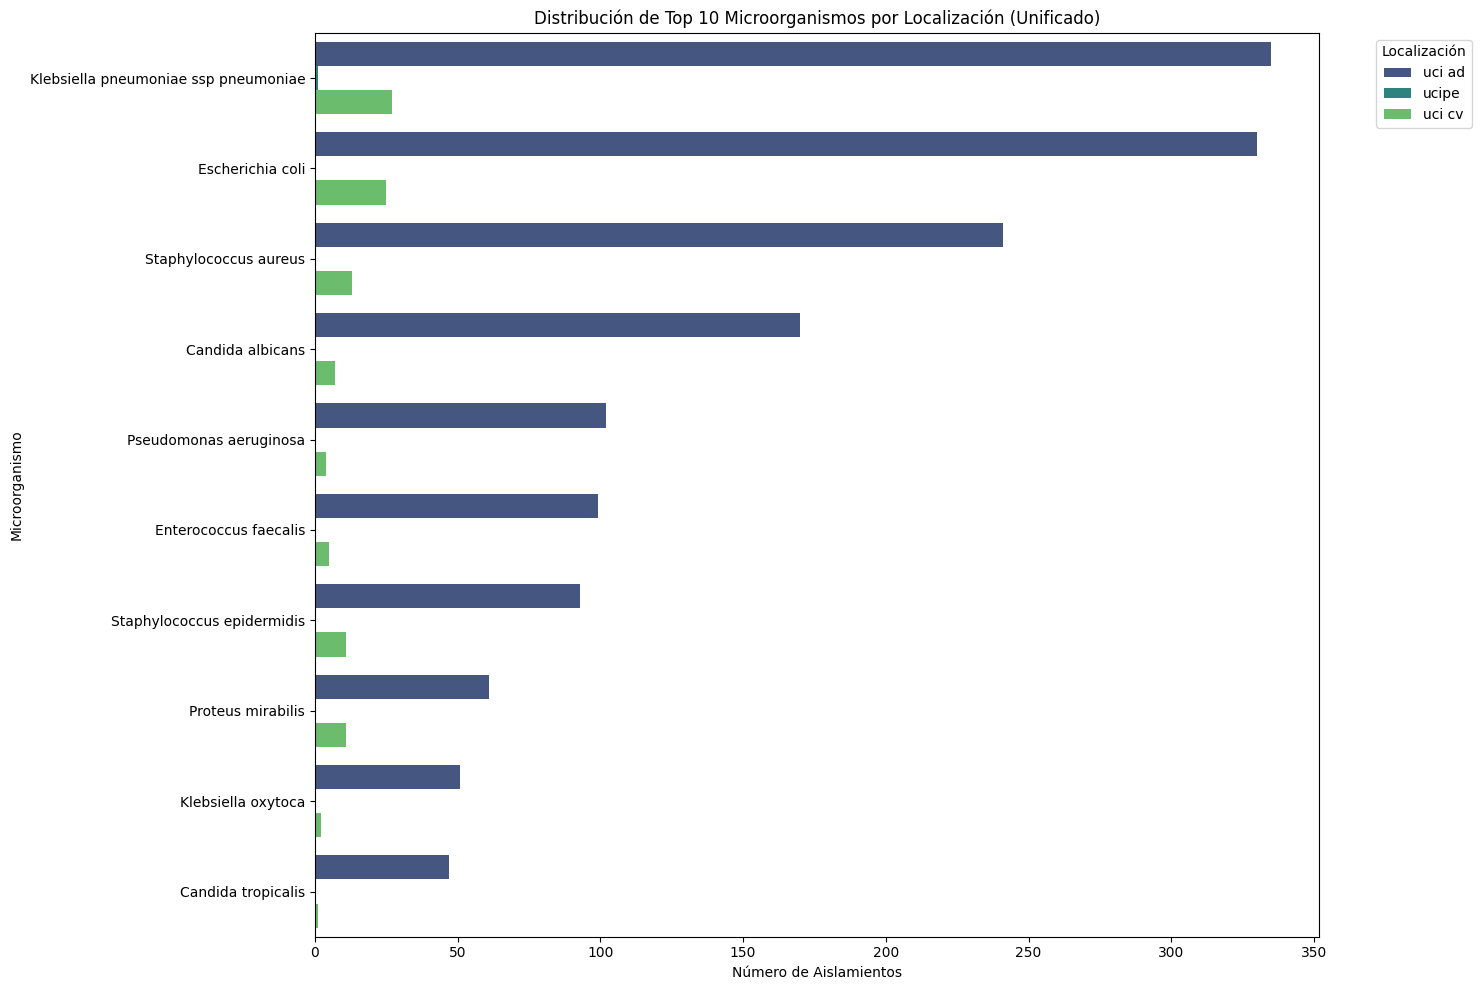

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the specific locations to include in the unified chart
specific_locations = ['uci ad', 'ucipe', 'uci cv']

# Filter the cleaned DataFrame for these specific locations and top 10 microorganisms
df_filtered_locations = df_adultos_cleaned[
    (df_adultos_cleaned['Localización'].isin(specific_locations)) &
    (df_adultos_cleaned['Microorganismo'].isin(top_10_microorganismos))
].copy()

# Group by Localización and Microorganismo, and count the frequency
microorganism_counts_unified = df_filtered_locations.groupby(['Localización', 'Microorganismo']).size().reset_index(name='Frecuencia')

# Map abbreviated names to full names for visualization
microorganism_counts_unified['Microorganismo_Full_Name'] = \
    microorganism_counts_unified['Microorganismo'].map(microorganism_name_map).fillna(microorganism_counts_unified['Microorganismo'])

# Ensure the 'Localización' column is categorical with a specific order for consistent plotting
microorganism_counts_unified['Localización'] = pd.Categorical(
    microorganism_counts_unified['Localización'], categories=specific_locations, ordered=True)

# Sort for better visualization if needed, e.g., by frequency within each location or overall
microorganism_counts_unified = microorganism_counts_unified.sort_values(by=['Localización', 'Frecuencia'], ascending=[True, False])

# Create the unified bar plot
plt.figure(figsize=(15, 10))
sns.barplot(data=microorganism_counts_unified,
            x='Frecuencia',
            y='Microorganismo_Full_Name',
            hue='Localización',
            palette='viridis')
plt.title('Distribución de Top 10 Microorganismos por Localización (Unificado)')
plt.xlabel('Número de Aislamientos')
plt.ylabel('Microorganismo')
plt.legend(title='Localización', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 14. Distribución de Tipos de Muestra en 'UCI ad'

Vamos a visualizar la distribución de los diferentes tipos de muestra recolectados específicamente en la localización 'uci ad'.

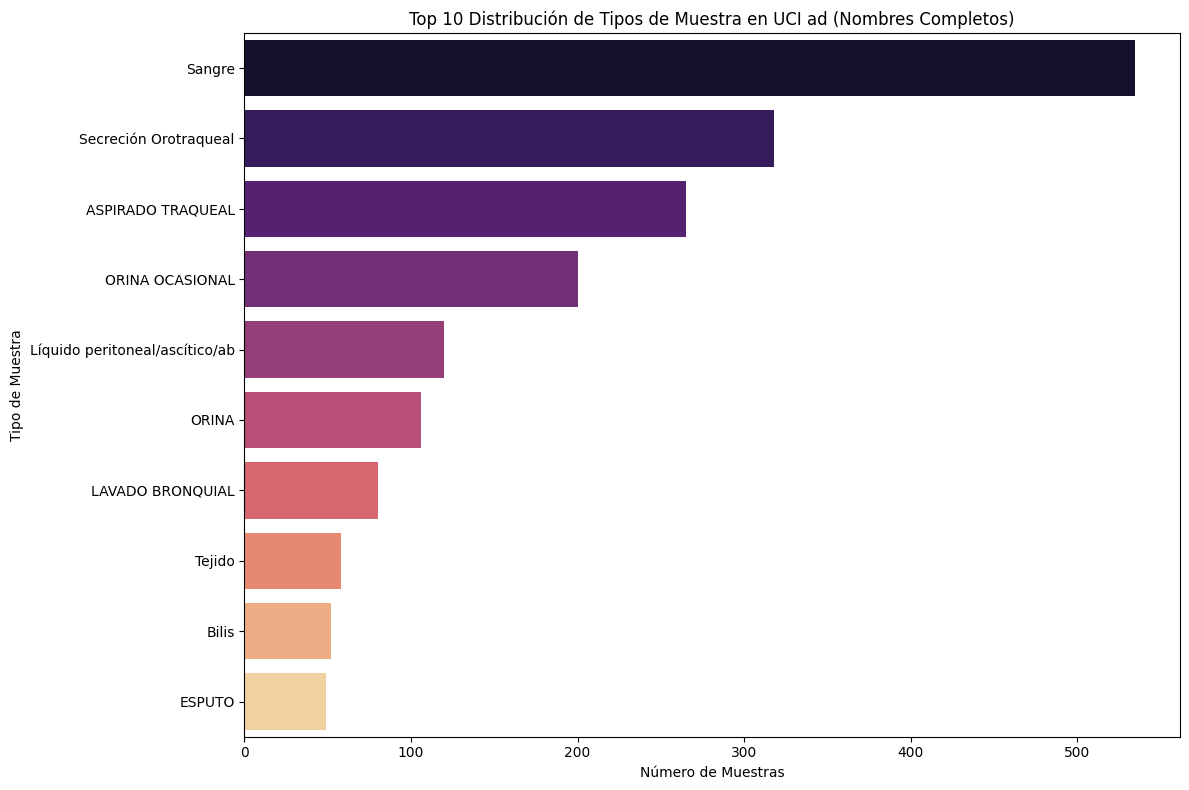

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filter the DataFrame for 'uci ad' location
df_uci_ad = df_adultos_cleaned[df_adultos_cleaned['Localización'] == 'uci ad'].copy()

# Get the distribution of 'Tipo de muestra' for 'uci ad'
sample_type_distribution_uci_ad = df_uci_ad['Tipo de muestra'].value_counts()

# Filter to show only the top 10 most frequent sample types
sample_type_distribution_uci_ad_top10 = sample_type_distribution_uci_ad.head(10)

# Create a mapping from 'Tipo de muestra' (abbreviation) to 'Código de muestra local' (full name)
sample_type_name_map = df_adultos_cleaned.dropna(subset=['Tipo de muestra', 'Código de muestra local']).drop_duplicates(subset=['Tipo de muestra']).set_index('Tipo de muestra')['Código de muestra local']

# Apply the mapping to get the full names for the top 10 sample types
top_10_sample_types_abbreviations = sample_type_distribution_uci_ad_top10.index
mapped_sample_type_names = top_10_sample_types_abbreviations.map(sample_type_name_map)
full_sample_type_names = mapped_sample_type_names.where(mapped_sample_type_names.notna(), top_10_sample_types_abbreviations)

# Prepare data for barplot
plot_data_sample_type = pd.DataFrame({
    'Frecuencia': sample_type_distribution_uci_ad_top10.values,
    'Tipo de Muestra_Full_Name': full_sample_type_names
})

# Create the bar plot
plt.figure(figsize=(12, 8))
sns.barplot(data=plot_data_sample_type,
            x='Frecuencia',
            y='Tipo de Muestra_Full_Name',
            hue='Tipo de Muestra_Full_Name', # Assign y variable to hue for coloring
            palette='magma',
            legend=False) # Set legend=False as recommended to avoid redundant legend
plt.title('Top 10 Distribución de Tipos de Muestra en UCI ad (Nombres Completos)')
plt.xlabel('Número de Muestras')
plt.ylabel('Tipo de Muestra')
plt.tight_layout()
plt.show()

## 15. Carga del Documento de Antibióticos para Evaluación de Resistencia

Ahora, cargaremos el archivo 'Antibioticos.xlsx' para poder evaluar la resistencia de los microorganismos.

In [ ]:
import pandas as pd

# Define the full path to the 'Antibioticos.xlsx' file in Google Drive
antibiotics_file_path = '/content/drive/MyDrive/BSD_Grebo/Antibioticos.xlsx'

try:
    # Read the Excel file into a pandas DataFrame
    df_antibioticos = pd.read_excel(antibiotics_file_path)
    print("Archivo 'Antibioticos.xlsx' cargado exitosamente.")

    # Display the first 5 rows of the DataFrame
    display(df_antibioticos.head())
except FileNotFoundError:
    print(f"Error: El archivo '{antibiotics_file_path}' no fue encontrado. Por favor, asegúrate de que la ruta y el nombre del archivo sean correctos y que Google Drive esté montado.")
except Exception as e:
    print(f"Ocurrió un error al leer el archivo Excel: {e}")
    print("Por favor, verifica la integridad del archivo y los permisos.")

Archivo 'Antibioticos.xlsx' cargado exitosamente.


,Código,Antibiótico,Resistente (R)
0,AMP,Ampicilina,≥ 16
1,AMC,Amoxicilina-ácido clavulánico,≥ 32/16
2,SAM,Ampicilina-sulbactam,≥ 32/16
3,TZP,Piperacilina-tazobactam,≥ 128/4
4,CZO,Cefazolina (Sistémico),≥ 4


##16. Carga del Documento de Resistencia para evaluación de resistencias

In [ ]:
# Reload df_resistencia, specifying the header as the second row (index 1)
df_resistencia_cleaned = pd.read_excel('/content/drive/MyDrive/BSD_Grebo/Resistencia.xlsx', header=1)

# Rename the first column for clarity
df_resistencia_cleaned = df_resistencia_cleaned.rename(columns={'Código de microorganismo local': 'Microorganismo'})

# Display the first few rows and info of the cleaned DataFrame
display(df_resistencia_cleaned.head())
print(df_resistencia_cleaned.info())

,Microorganismo,AMK,AMX,AMP,SAM,ATM,CEP,CZO,FEP,CTX,...,TEC,TLT,TCY,TGC,TOB,SXT,VAN,VOR,X_2,FOS
0,Acinetobacter baumannii/calcoaceticus co,<=8,NaN,>16,>16,NaN,NaN,>8,<=1,NaN,...,NaN,NaN,NaN,<=1,NaN,>2,NaN,NaN,NaN,64
1,Acinetobacter baumannii,NaN,NaN,NaN,>16,NaN,NaN,NaN,>16,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Acinetobacter baumannii complex,NaN,NaN,NaN,<=2,NaN,NaN,NaN,16,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Acinetobacter baumannii,<=8,NaN,>16,NaN,NaN,NaN,>16,4,NaN,...,NaN,NaN,>8,NaN,NaN,<=.5,NaN,NaN,NaN,NaN
4,Acinetobacter baumannii,<=8,NaN,>16,<=4,NaN,NaN,>16,2,NaN,...,NaN,NaN,NaN,<=1,NaN,<=1,NaN,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2033 entries, 0 to 2032
Data columns (total 54 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Microorganismo  2023 non-null   object 
 1   AMK             1210 non-null   object 
 2   AMX             0 non-null      float64
 3   AMP             387 non-null    object 
 4   SAM             935 non-null    object 
 5   ATM             669 non-null    object 
 6   CEP             0 non-null      float64
 7   CZO             387 non-null    object 
 8   FEP             1206 non-null   object 
 9   CTX             113 non-null    object 
 10  CTT             0 non-null      float64
 11  FOX             492 non-null    object 
 12  CAZ             1249 non-null   object 
 13  CRO             564 non-null    object 
 14  CXM             144 non-null    object 
 15  CXA             86 non-null     object 
 16  CIP             1818 non-null   object 
 17  CLI             363 non-null    o

### Vista Previa del Documento 'Resistencia.xlsx' Original

Primero, cargaremos y mostraremos las primeras filas del archivo 'Resistencia.xlsx' sin aplicar ninguna limpieza de encabezado, para que puedas ver el contenido original.

In [ ]:
import pandas as pd

resistencia_file_path = '/content/drive/MyDrive/BSD_Grebo/Resistencia.xlsx'

print("Primeras filas del documento 'Resistencia.xlsx' original:")
df_resistencia_raw = pd.read_excel(resistencia_file_path)
display(df_resistencia_raw.head())


Primeras filas del documento 'Resistencia.xlsx' original:


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 44,Unnamed: 45,Unnamed: 46,Unnamed: 47,Unnamed: 48,Unnamed: 49,Unnamed: 50,Unnamed: 51,Unnamed: 52,Unnamed: 53
0,Código de microorganismo local,AMK,AMX,AMP,SAM,ATM,CEP,CZO,FEP,CTX,...,TEC,TLT,TCY,TGC,TOB,SXT,VAN,VOR,X_2,FOS
1,Acinetobacter baumannii/calcoaceticus co,<=8,NaN,>16,>16,NaN,NaN,>8,<=1,NaN,...,NaN,NaN,NaN,<=1,NaN,>2,NaN,NaN,NaN,64
2,Acinetobacter baumannii,NaN,NaN,NaN,>16,NaN,NaN,NaN,>16,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Acinetobacter baumannii complex,NaN,NaN,NaN,<=2,NaN,NaN,NaN,16,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Acinetobacter baumannii,<=8,NaN,>16,NaN,NaN,NaN,>16,4,NaN,...,NaN,NaN,>8,NaN,NaN,<=.5,NaN,NaN,NaN,NaN


### Primeras Filas de `df_resistencia_cleaned`

Ahora, te muestro las primeras filas del DataFrame `df_resistencia_cleaned` que ya fue cargado y tiene el encabezado ajustado.

In [ ]:
display(df_resistance_summary)

NameError: name 'df_resistance_summary' is not defined

In [ ]:
print("Primeras filas de df_resistencia_cleaned (con encabezado ajustado):")
display(df_resistencia_cleaned.head())

Primeras filas de df_resistencia_cleaned (con encabezado ajustado):


,Microorganismo,AMK,AMX,AMP,SAM,ATM,CEP,CZO,FEP,CTX,...,IPM_MIC_Numeric,MEM_MIC_Numeric,CIP_MIC_Numeric,LVX_MIC_Numeric,AMK_MIC_Numeric,GEN_MIC_Numeric,SXT_MIC_Numeric,FOS_MIC_Numeric,NIT_MIC_Numeric,TOB_MIC_Numeric
0,Acinetobacter baumannii/calcoaceticus co,<=8,NaN,>16,>16,NaN,NaN,>8,<=1,NaN,...,0.25,0.5,0.125,1.0,8.0,8.0,2.0,64.0,NaN,NaN
1,Acinetobacter baumannii,NaN,NaN,NaN,>16,NaN,NaN,NaN,>16,NaN,...,8.00,8.0,2.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Acinetobacter baumannii complex,NaN,NaN,NaN,<=2,NaN,NaN,NaN,16,NaN,...,8.00,8.0,0.500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Acinetobacter baumannii,<=8,NaN,>16,NaN,NaN,NaN,>16,4,NaN,...,0.25,0.5,0.250,1.0,8.0,2.0,0.5,NaN,64.0,NaN
4,Acinetobacter baumannii,<=8,NaN,>16,<=4,NaN,NaN,>16,2,NaN,...,1.00,1.0,2.000,NaN,8.0,2.0,1.0,NaN,NaN,NaN


## 17. Evaluación de la Resistencia a los Antibióticos

Vamos a utilizar el documento de antibióticos (`df_antibioticos`) y el de resistencia (`df_resistencia_cleaned`) para determinar y resumir la cantidad de microorganismos resistentes para cada antibiótico.

In [ ]:
import re
import pandas as pd

# Function to parse the resistance threshold from the 'Resistente (R)' string
def parse_resistance_threshold(resistance_str):
    if isinstance(resistance_str, str):
        # Remove common comparison operators (>=, ≥, >) and leading/trailing spaces
        s = resistance_str.replace('>=', '').replace('≥', '').replace('>', '').strip()
        # If there's a '/', take only the first part (e.g., '32/16' becomes '32')
        if '/' in s:
            s = s.split('/')[0]
        try:
            return float(s)
        except ValueError:
            return None # Return None for unparseable strings
    return None

# Apply the parser to create a new column with numeric resistance thresholds in df_antibioticos
df_antibioticos['Resistencia_Threshold'] = df_antibioticos['Resistente (R)'].apply(parse_resistance_threshold)

# Prepare a dictionary for easy lookup of resistance thresholds by antibiotic code
resistance_thresholds = df_antibioticos.set_index('Código')['Resistencia_Threshold'].to_dict()

# Initialize a dictionary to store resistance counts for each antibiotic
antibiotic_resistance_counts = {code: 0 for code in resistance_thresholds.keys()}

# Iterate through each antibiotic in our df_antibioticos to check resistance in df_resistencia_cleaned
for antibiotic_code, threshold in resistance_thresholds.items():
    if threshold is not None and antibiotic_code in df_resistencia_cleaned.columns:
        # A more robust way to convert MIC values to comparable floats
        def mic_to_float(mic_value):
            if isinstance(mic_value, str):
                mic_value_lower = mic_value.strip().lower()
                if mic_value_lower == 'r':
                    return float('inf') # Treat 'R' as infinitely resistant
                if mic_value_lower == 's':
                    return float('-inf') # Treat 'S' as infinitely sensitive

                # Proceed with numerical parsing for other string values
                mic_value = mic_value.replace('<', '').replace('=', '').replace('>', '').strip()
                if '/' in mic_value:
                    mic_value = mic_value.split('/')[0]
                try:
                    return float(mic_value)
                except ValueError:
                    return None # Return None for other unparseable strings
            elif isinstance(mic_value, (int, float)):
                return float(mic_value)
            return None # Return None for other types (e.g., NaN)

        df_resistencia_cleaned[antibiotic_code + '_MIC_Numeric'] = df_resistencia_cleaned[antibiotic_code].apply(mic_to_float)

        # Count how many microorganisms are resistant for this antibiotic
        # A microorganism is resistant if its MIC is greater than or equal to the threshold
        if antibiotic_code + '_MIC_Numeric' in df_resistencia_cleaned.columns:
            # Filter out NaNs from the MIC_Numeric column before comparison
            relevant_mic_values = df_resistencia_cleaned[df_resistencia_cleaned[antibiotic_code + '_MIC_Numeric'].notna()][antibiotic_code + '_MIC_Numeric']
            resistant_count = relevant_mic_values[relevant_mic_values >= threshold].shape[0]
            antibiotic_resistance_counts[antibiotic_code] = resistant_count

# Convert the results to a DataFrame for better display
df_resistance_summary = pd.DataFrame(antibiotic_resistance_counts.items(), columns=['Código', 'Resistant_Microorganism_Count'])

# Merge with the original df_antibioticos to add antibiotic names and resistance thresholds
df_resistance_summary = pd.merge(df_resistance_summary, df_antibioticos[['Código', 'Antibiótico', 'Resistente (R)', 'Resistencia_Threshold']], on='Código', how='left')

# Reorder and rename columns for final display
df_resistance_summary = df_resistance_summary[['Antibiótico', 'Resistente (R)', 'Resistencia_Threshold', 'Resistant_Microorganism_Count']]

display(df_resistance_summary)

,Antibiótico,Resistente (R),Resistencia_Threshold,Resistant_Microorganism_Count
0,Ampicilina,≥ 16,16.0,157
1,Amoxicilina-ácido clavulánico,≥ 32/16,32.0,0
2,Ampicilina-sulbactam,≥ 32/16,32.0,0
3,Piperacilina-tazobactam,≥ 128/4,128.0,0
4,Cefazolina (Sistémico),≥ 4,4.0,107
5,Cefazolina (Urinario),≥ 32,32.0,107
6,Cefuroxima (Parenteral),≥ 32,32.0,24
7,Ceftriaxona,≥ 4,4.0,134
8,Cefotaxima,≥ 4,4.0,292
9,Ceftacidima,≥ 16,16.0,315


##18. Los 10 microorganismos más frecuentes en UCI

Top 10 Microorganismos más frecuentes en UCI Adultos (con nombres completos mapeados):



,0
Microorganismo,
Klebsiella pneumoniae ssp pneumoniae,335
Escherichia coli,330
Staphylococcus aureus,241
Candida albicans,170
Pseudomonas aeruginosa,102
Enterococcus faecalis,99
Staphylococcus epidermidis,93
Proteus mirabilis,61
Klebsiella oxytoca,51


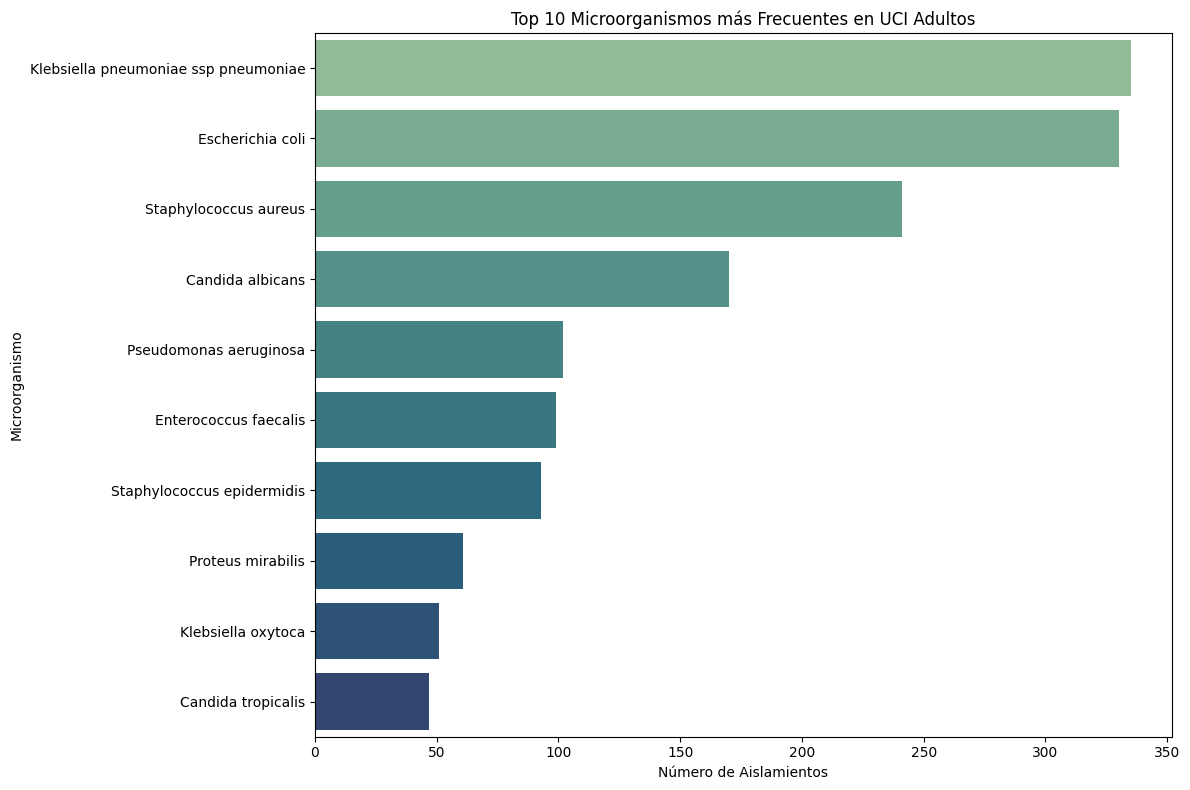

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filtrar el DataFrame df_adultos para la localización 'uci ad' (UCI adultos)
df_uci_adultos_frequent = df_adultos_cleaned[df_adultos_cleaned['Localización'] == 'uci ad'].copy()

# Contar la frecuencia de cada microorganismo en 'uci ad'
microorganismo_counts_uci_ad = df_uci_adultos_frequent['Microorganismo'].value_counts(dropna=False)

# Obtener los 10 microorganismos más frecuentes por sus códigos abreviados
top_10_abbreviations_uci_ad = microorganismo_counts_uci_ad.head(10).index

# Mapear los nombres abreviados a los nombres completos para la leyenda
# Usamos microorganism_name_map que ya se definió previamente
mapped_names_series_uci_ad = top_10_abbreviations_uci_ad.map(microorganism_name_map)

# Si un nombre completo no se encuentra para una abreviatura, usa la abreviatura misma
top_microorganismos_full_names_uci_ad = mapped_names_series_uci_ad.where(mapped_names_series_uci_ad.notna(), top_10_abbreviations_uci_ad)

print("Top 10 Microorganismos más frecuentes en UCI Adultos (con nombres completos mapeados):\n")
display(pd.Series(microorganismo_counts_uci_ad.head(10).values, index=top_microorganismos_full_names_uci_ad))

# Visualizar la distribución de los 10 microorganismos más frecuentes
plt.figure(figsize=(12, 8))
sns.barplot(x=microorganismo_counts_uci_ad.head(10).values, y=top_microorganismos_full_names_uci_ad, palette='crest', hue=top_microorganismos_full_names_uci_ad, legend=False)
plt.title('Top 10 Microorganismos más Frecuentes en UCI Adultos')
plt.xlabel('Número de Aislamientos')
plt.ylabel('Microorganismo')
plt.tight_layout()
plt.show()

## 19. Visualización de Antibióticos con Mayor Resistencia

Ahora, graficaremos los antibióticos que presentan el mayor número de microorganismos resistentes, basándonos en la evaluación que acabamos de realizar.

Los 10 microorganismos más frecuentes en UCI Adultos, ordenados por resistencia promedio:


,0
Klebsiella pneumoniae ssp pneumoniae,3.356688
Staphylococcus epidermidis,2.471154
Klebsiella oxytoca,1.460000
Escherichia coli,1.455621
Pseudomonas aeruginosa,1.425743
Proteus mirabilis,0.900000
Staphylococcus aureus,0.800000
Enterococcus faecalis,0.336735


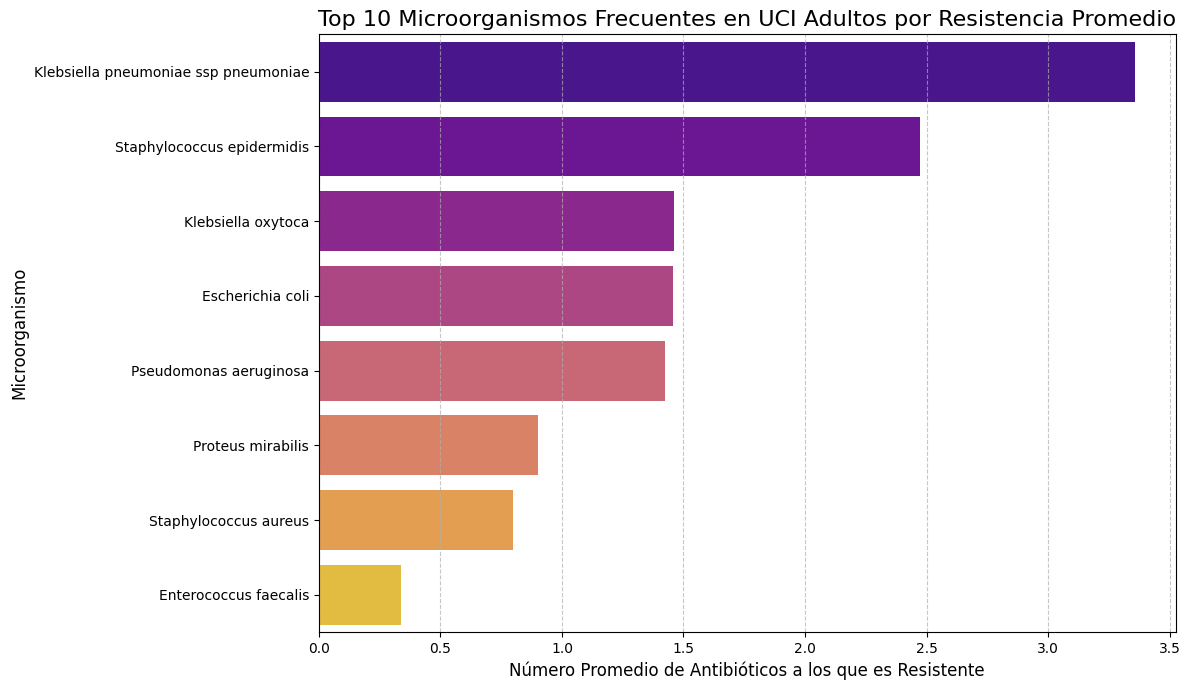

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re

# --- Helper functions (from previous steps, ensuring they are defined) ---
def parse_resistance_threshold(resistance_str):
    if isinstance(resistance_str, str):
        s = resistance_str.replace('>=', '').replace('≥', '').replace('>', '').strip()
        if '/' in s:
            s = s.split('/')[0]
        try:
            return float(s)
        except ValueError:
            return None
    return None

def mic_to_float(mic_value):
    if isinstance(mic_value, str):
        mic_value_lower = mic_value.strip().lower()
        if mic_value_lower == 'r':
            return float('inf')
        if mic_value_lower == 's':
            return float('-inf')
        mic_value = mic_value.replace('<', '').replace('=', '').replace('>', '').strip()
        if '/' in mic_value:
            mic_value = mic_value.split('/')[0]
        try:
            return float(mic_value)
        except ValueError:
            return None
    elif isinstance(mic_value, (int, float)):
        return float(mic_value)
    return None

# Recalculate resistance_thresholds from df_antibioticos for robustness
df_antibioticos['Resistencia_Threshold'] = df_antibioticos['Resistente (R)'].apply(parse_resistance_threshold)
resistance_thresholds = df_antibioticos.set_index('Código')['Resistencia_Threshold'].to_dict()

# Calculate resistance score per isolation in df_resistencia_cleaned
antibiotic_cols_in_resistencia_and_thresholds = [
    col for col in df_resistencia_cleaned.columns
    if col in resistance_thresholds and col != 'Microorganismo'
]

df_resistance_analysis = df_resistencia_cleaned[['Microorganismo']].copy()
df_resistance_analysis['Resistance_Score'] = 0

for ab_code in antibiotic_cols_in_resistencia_and_thresholds:
    threshold = resistance_thresholds[ab_code]
    mic_values = df_resistencia_cleaned[ab_code].apply(mic_to_float)
    df_resistance_analysis['Resistance_Score'] += (mic_values >= threshold).fillna(False).astype(int)

# Aggregate resistance score by full microorganism name
microorganism_resistance_scores_df = df_resistance_analysis.groupby('Microorganismo')['Resistance_Score'].mean().reset_index()
microorganism_resistance_scores_df.rename(columns={'Microorganismo': 'Microorganismo_Full_Name',
                                                     'Resistance_Score': 'Mean_Resistance_Score_Per_Isolation'},
                                            inplace=True)
microorganism_resistance_scores = microorganism_resistance_scores_df.set_index('Microorganismo_Full_Name')['Mean_Resistance_Score_Per_Isolation'].to_dict()


# 1. Get the list of top 10 most frequent microorganisms in UCI adults
# This was previously calculated in cell `1bcd57aa` as `top_microorganismos_full_names_uci_ad`
# Let's re-derive it here for robustness if the previous cell was not run
df_uci_adultos_frequent = df_adultos_cleaned[df_adultos_cleaned['Localización'] == 'uci ad'].copy()
microorganismo_counts_uci_ad = df_uci_adultos_frequent['Microorganismo'].value_counts(dropna=False)

top_10_abbreviations_uci_ad = microorganismo_counts_uci_ad.head(10).index

# Ensure microorganism_name_map is available (it's defined in ee58c7ce)
# If running this cell independently, ensure microorganism_name_map is loaded/created.
# For this context, it is assumed to be available from previous execution.
if 'microorganism_name_map' not in locals() and 'microorganism_name_map' not in globals():
    # Fallback to create it if not already present (e.g., if previous cells skipped)
    microorganism_name_map = df_adultos_cleaned.dropna(subset=['Microorganismo', 'Código de microorganismo local']).drop_duplicates(subset=['Microorganismo']).set_index('Microorganismo')['Código de microorganismo local']

mapped_names_series_uci_ad = top_10_abbreviations_uci_ad.map(microorganism_name_map)
top_microorganismos_full_names_uci_ad = mapped_names_series_uci_ad.where(mapped_names_series_uci_ad.notna(), top_10_abbreviations_uci_ad).tolist()


# 2. Filter the overall resistance scores for these top 10 frequent microorganisms
resistance_scores_for_top_frequent_uci = {
    name: microorganism_resistance_scores.get(name, 0) # Get score, default to 0 if not found
    for name in top_microorganismos_full_names_uci_ad
    if name in microorganism_resistance_scores # Only include if resistance data exists for this microorganism
}

# Convert to pandas Series for easy sorting and plotting
df_top_frequent_resistant_uci = pd.Series(resistance_scores_for_top_frequent_uci).sort_values(ascending=False)

if not df_top_frequent_resistant_uci.empty:
    print("Los 10 microorganismos más frecuentes en UCI Adultos, ordenados por resistencia promedio:")
    display(df_top_frequent_resistant_uci)

    # Plotting
    plt.figure(figsize=(12, 7))
    sns.barplot(x=df_top_frequent_resistant_uci.values, y=df_top_frequent_resistant_uci.index, palette='plasma', hue=df_top_frequent_resistant_uci.index, legend=False)
    plt.title('Top 10 Microorganismos Frecuentes en UCI Adultos por Resistencia Promedio', fontsize=16)
    plt.xlabel('Número Promedio de Antibióticos a los que es Resistente', fontsize=12)
    plt.ylabel('Microorganismo', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("No se encontraron datos de resistencia para los 10 microorganismos más frecuentes en UCI Adultos con los mapeos proporcionados.")

Los 10 microorganismos más resistentes en UCI Adultos son:


,0
Acinetobacter lwoffii,7.000000
Elizabethkingia meningoseptica,6.000000
Aeromonas veronii bv veronii,5.000000
Burkholderia cepacia complejo,5.000000
Pandorea apista,5.000000
Burkholderia cepacia,4.250000
Providencia rettgeri,4.250000
Achromobacter xylosoxidans,4.000000
Delftia acidovorans,4.000000
Staphylococcus haemolyticus,3.631579


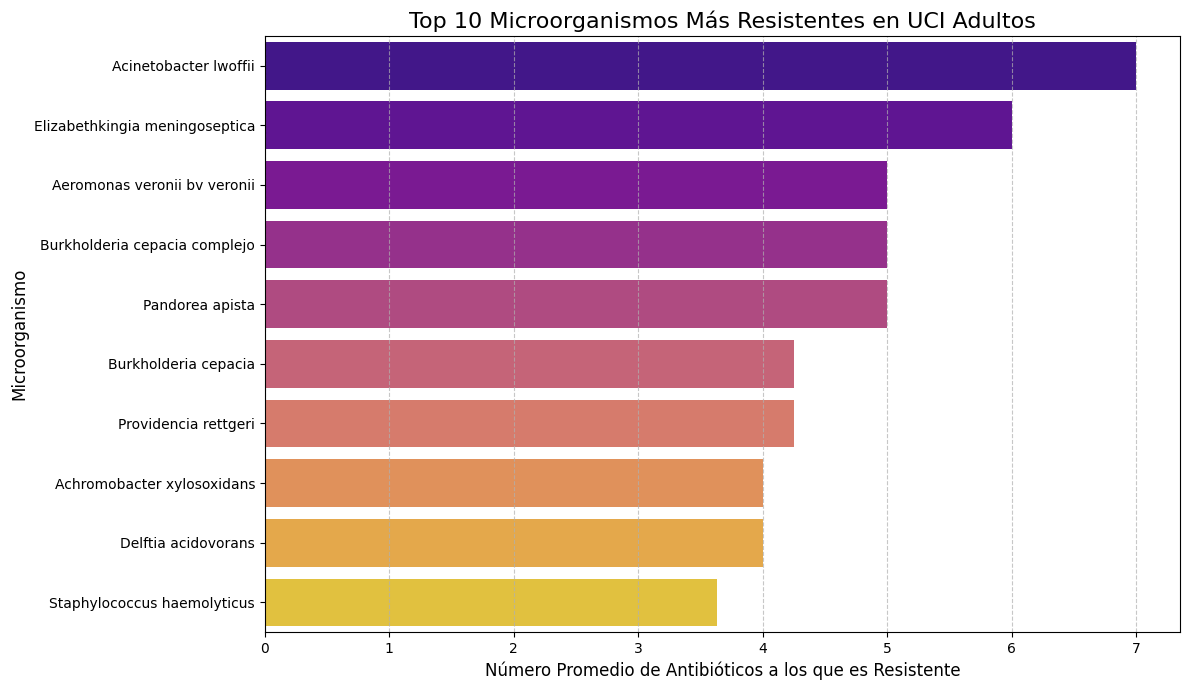

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re

# --- Helper functions (from previous steps, ensuring they are defined) ---
def parse_resistance_threshold(resistance_str):
    if isinstance(resistance_str, str):
        s = resistance_str.replace('>=', '').replace('≥', '').replace('>', '').strip()
        if '/' in s:
            s = s.split('/')[0]
        try:
            return float(s)
        except ValueError:
            return None
    return None

def mic_to_float(mic_value):
    if isinstance(mic_value, str):
        mic_value_lower = mic_value.strip().lower()
        if mic_value_lower == 'r':
            return float('inf')
        if mic_value_lower == 's':
            return float('-inf')
        mic_value = mic_value.replace('<', '').replace('=', '').replace('>', '').strip()
        if '/' in mic_value:
            mic_value = mic_value.split('/')[0]
        try:
            return float(mic_value)
        except ValueError:
            return None
    elif isinstance(mic_value, (int, float)):
        return float(mic_value)
    return None

# Re-create resistance_thresholds from df_antibioticos for robust execution
df_antibioticos['Resistencia_Threshold'] = df_antibioticos['Resistente (R)'].apply(parse_resistance_threshold)
resistance_thresholds = df_antibioticos.set_index('Código')['Resistencia_Threshold'].to_dict()

# Step 1: Calculate resistance score per isolation in df_resistencia_cleaned
# Identify antibiotic columns from df_resistencia_cleaned that are also in resistance_thresholds
antibiotic_cols_in_resistencia_and_thresholds = [
    col for col in df_resistencia_cleaned.columns
    if col in resistance_thresholds and col != 'Microorganismo'
]

# Create a copy to add resistance scores without modifying the original df_resistencia_cleaned in place for this calculation
df_resistance_analysis = df_resistencia_cleaned[['Microorganismo']].copy()
df_resistance_analysis['Resistance_Score'] = 0

for ab_code in antibiotic_cols_in_resistencia_and_thresholds:
    threshold = resistance_thresholds[ab_code]
    mic_values = df_resistencia_cleaned[ab_code].apply(mic_to_float)
    df_resistance_analysis['Resistance_Score'] += (mic_values >= threshold).fillna(False).astype(int)

# Aggregate resistance score by full microorganism name to get the average resistance score for each microorganism
microorganism_resistance_scores_df = df_resistance_analysis.groupby('Microorganismo')['Resistance_Score'].mean().reset_index()
microorganism_resistance_scores_df.rename(columns={'Microorganismo': 'Microorganismo_Full_Name',
                                                     'Resistance_Score': 'Mean_Resistance_Score_Per_Isolation'},
                                            inplace=True)

# Convert to a dictionary for easy lookup by full microorganism name
microorganism_resistance_scores = microorganism_resistance_scores_df.set_index('Microorganismo_Full_Name')['Mean_Resistance_Score_Per_Isolation'].to_dict()

# --- User's provided code, adapted to use the newly created 'microorganism_resistance_scores' ---

# Filtrar el DataFrame df_adultos para la localización 'uci ad' (UCI adultos)
df_uci_adultos_filtered = df_adultos_cleaned[df_adultos_cleaned['Localización'] == 'uci ad'].copy()

# Create a robust map from codes in df_adultos to full names used in df_resistencia_cleaned
# Start with the hardcoded ones
robust_code_to_full_name_map = {
    'kpn': 'Klebsiella pneumoniae ssp pneumoniae',
    'eco': 'Escherichia coli',
    'sau': 'Staphylococcus aureus',
    'ecl': 'Enterobacter cloacae',
    'pae': 'Pseudomonas aeruginosa',
    'efa': 'Enterococcus faecalis',
    'pmi': 'Proteus mirabilis',
    'kox': 'Klebsiella oxytoca',
    'ctr': 'Citrobacter freundii',
    'cal': 'Candida albicans',
    'sep': 'Staphylococcus epidermidis',
}
# Augment with dynamically generated map from df_adultos_cleaned, overwriting if keys are identical
robust_code_to_full_name_map.update(microorganism_name_map.to_dict())

# Get unique microorganism codes present in the filtered UCI adults DataFrame
unique_microorganism_codes_uci_ad = df_uci_adultos_filtered['Microorganismo'].dropna().unique()

# Initialize dictionary to store resistance scores for microorganisms found in 'uci ad'
uci_resistance_scores_mapped = {}

for code_in_uci_ad in unique_microorganism_codes_uci_ad:
    # Attempt to get the full name from our robust mapping
    full_name = robust_code_to_full_name_map.get(code_in_uci_ad)

    # If a full name was found and that full name exists as a key in our pre-calculated resistance scores
    if full_name and full_name in microorganism_resistance_scores:
        uci_resistance_scores_mapped[full_name] = microorganism_resistance_scores[full_name]

# Convert to pandas Series for easy sorting and finding the top 10
uci_resistance_series = pd.Series(uci_resistance_scores_mapped)

if not uci_resistance_series.empty:
    top_10_resistant_uci = uci_resistance_series.nlargest(10)
    print("Los 10 microorganismos más resistentes en UCI Adultos son:")
    display(top_10_resistant_uci)

    # Plotting the top 10 most resistant microorganisms in UCI adults
    plt.figure(figsize=(12, 7))
    sns.barplot(x=top_10_resistant_uci.values, y=top_10_resistant_uci.index, palette='plasma', hue=top_10_resistant_uci.index, legend=False)
    plt.title('Top 10 Microorganismos Más Resistentes en UCI Adultos', fontsize=16)
    plt.xlabel('Número Promedio de Antibióticos a los que es Resistente', fontsize=12)
    plt.ylabel('Microorganismo', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("No se encontraron datos de resistencia para los microorganismos en UCI Adultos con los mapeos proporcionados.")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ============================================================
# FUNCIONES AUXILIARES
# ============================================================

def parse_resistance_threshold(resistance_str):
    if isinstance(resistance_str, str):
        s = resistance_str.replace('>=', '').replace('≥', '').replace('>', '').strip()

        if '/' in s:
            s = s.split('/')[0]

        try:
            return float(s)
        except ValueError:
            return None

    return None


def mic_to_float(mic_value):

    if pd.isna(mic_value):
        return None

    if isinstance(mic_value, str):

        mic_value_lower = mic_value.strip().lower()

        if mic_value_lower == 'r':
            return float('inf')

        if mic_value_lower == 's':
            return float('-inf')

        mic_value = (
            mic_value
            .replace('<', '')
            .replace('>', '')
            .replace('=', '')
            .strip()
        )

        if '/' in mic_value:
            mic_value = mic_value.split('/')[0]

        try:
            return float(mic_value)
        except ValueError:
            return None

    elif isinstance(mic_value, (int, float)):
        return float(mic_value)

    return None


# ============================================================
# CREAR UMBRALES DE RESISTENCIA
# ============================================================

# Define the full path to the 'Antibioticos.xlsx' file in Google Drive
antibiotics_file_path = '/content/drive/MyDrive/BSD_Grebo/Antibioticos.xlsx'
df_antibioticos = pd.read_excel(antibiotics_file_path)

df_antibioticos['Resistencia_Threshold'] = (
    df_antibioticos['Resistente (R)']
    .apply(parse_resistance_threshold)
)

resistance_thresholds = (
    df_antibioticos
    .set_index('Código')['Resistencia_Threshold']
    .to_dict()
)

# ============================================================
# IDENTIFICAR COLUMNAS DE ANTIBIÓTICOS
# ============================================================

antibiotic_cols = [
    col
    for col in df_resistencia_cleaned.columns
    if col in resistance_thresholds
]
# ============================================================
# CALCULAR SCORE DE RESISTENCIA POR AISLAMIENTO
# ============================================================

df_resistance_analysis = (
    df_resistencia_cleaned[['Microorganismo']]
    .copy()
)

df_resistance_analysis['Resistance_Score'] = 0

for ab_code in antibiotic_cols:

    threshold = resistance_thresholds.get(ab_code)

    if pd.isna(threshold):
        continue

    mic_values = (
        df_resistencia_cleaned[ab_code]
        .apply(mic_to_float)
    )

    resistant = (
        mic_values >= threshold
    ).fillna(False).astype(int)

    df_resistance_analysis['Resistance_Score'] += resistant

# ============================================================
# PROMEDIO Y NÚMERO DE AISLAMIENTOS
# ============================================================

microorganism_resistance_scores_df = (
    df_resistance_analysis
    .groupby('Microorganismo')
    .agg(
        Mean_Resistance_Score=('Resistance_Score', 'mean'),
        N_Aislamientos=('Resistance_Score', 'size')
    )
    .reset_index()
)

# ============================================================
# FILTRO DE CALIDAD
# EXCLUIR MICROORGANISMOS MUY RAROS
# ============================================================

MIN_AISLAMIENTOS = 10

microorganism_resistance_scores_df = (
    microorganism_resistance_scores_df[
        microorganism_resistance_scores_df['N_Aislamientos']
        >= MIN_AISLAMIENTOS
    ]
)

# ============================================================
# DICCIONARIO DE SCORES
# ============================================================

microorganism_resistance_scores = (
    microorganism_resistance_scores_df
    .set_index('Microorganismo')['Mean_Resistance_Score']
    .to_dict()
)

# ============================================================
# FILTRAR UCI ADULTOS
# ============================================================

df_uci_adultos_filtered = (
    df_adultos_cleaned[
        df_adultos_cleaned['Localización']
        .str.lower()
        .eq('uci ad')
    ]
    .copy()
)

# ============================================================
# MAPEO DE CÓDIGOS A NOMBRES COMPLETOS
# ============================================================

robust_code_to_full_name_map = {
    'kpn': 'Klebsiella pneumoniae ssp pneumoniae',
    'eco': 'Escherichia coli',
    'sau': 'Staphylococcus aureus',
    'ecl': 'Enterobacter cloacae',
    'pae': 'Pseudomonas aeruginosa',
    'efa': 'Enterococcus faecalis',
    'pmi': 'Proteus mirabilis',
    'kox': 'Klebsiella oxytoca',
    'ctr': 'Citrobacter freundii',
    'cal': 'Candida albicans',
    'sep': 'Staphylococcus epidermidis'
}

robust_code_to_full_name_map.update(
    microorganism_name_map.to_dict()
)

# ============================================================
# MICROORGANISMOS PRESENTES EN UCI
# ============================================================

unique_codes = (
    df_uci_adultos_filtered['Microorganismo']
    .dropna()
    .unique()
)

uci_resistance_scores_mapped = {}

for code in unique_codes:

    full_name = robust_code_to_full_name_map.get(code)

    if (
        full_name is not None
        and full_name in microorganism_resistance_scores
    ):
        uci_resistance_scores_mapped[full_name] = (
            microorganism_resistance_scores[full_name]
        )

# ============================================================
# TOP 10
# ============================================================

uci_resistance_series = pd.Series(
    uci_resistance_scores_mapped
)

if not uci_resistance_series.empty:

    top_10 = (
        uci_resistance_series
        .sort_values(ascending=False)
        .head(10)
    )

    print("\nTOP 10 MICROORGANISMOS MÁS RESISTENTES")
    print(top_10)

    # --------------------------------------------------------
    # GRAFICAR
    # --------------------------------------------------------

    plt.figure(figsize=(12, 7))

    sns.barplot(
        x=top_10.values,
        y=top_10.index,
        palette='plasma'
    )

    plt.title(
        'Top 10 Microorganismos Más Resistentes en UCI Adultos',
        fontsize=15
    )

    plt.xlabel(
        'Número promedio de antibióticos resistentes',
        fontsize=12
    )

    plt.ylabel(
        'Microorganismo',
        fontsize=12
    )

    plt.grid(
        axis='x',
        linestyle='--',
        alpha=0.5
    )

    plt.tight_layout()
    plt.show()

else:

    print(
        "No se encontraron microorganismos con datos suficientes."
    )

# ============================================================
# TABLA DE APOYO
# ============================================================

print("\nMicroorganismos con más resistencia y n>=10\n")

display(
    microorganism_resistance_scores_df
    .sort_values(
        'Mean_Resistance_Score',
        ascending=False
    )
    .head(20)
)


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/BSD_Grebo/Antibioticos.xlsx'

In [ ]:
# Filtrar el DataFrame df_adultos para la localización 'uci ad' (UCI adultos)
df_uci_adultos_filtered = df_adultos[df_adultos['Localización'] == 'uci ad'].copy()

# Mapping from df_adultos codes to df_resistencia_cleaned full names
microorganism_code_to_full_name_map = {
    'kpn': 'Klebsiella pneumoniae',
    'eco': 'Escherichia coli',
    'sau': 'Staphylococcus aureus',
    'ecl': 'Enterobacter cloacae',
    'pae': 'Pseudomonas aeruginosa',
    'efa': 'Enterococcus faecalis',
    'pmi': 'Proteus mirabilis',
    'kox': 'Klebsiella oxytoca',
    'ctr': 'Citrobacter freundii', # Assuming ctr maps to Citrobacter freundii based on context
    'cal': 'Candida albicans', # Assuming cal maps to Candida albicans
    'sep': 'Staphylococcus epidermidis', # Assuming sep maps to Staphylococcus epidermidis
    # Add more mappings here if other codes are expected to be in top 10
}

# Get unique microorganism codes present in the filtered UCI adults DataFrame
unique_microorganism_codes_uci = df_uci_adultos_filtered['Microorganismo'].dropna().unique()

# Get the full names for these codes using our map.
# Also include any full names that might directly be present in unique_microorganism_codes_uci (for robustness).
full_names_in_uci_adults = []
for code in unique_microorganism_codes_uci:
    if code in microorganism_code_to_full_name_map:
        full_names_in_uci_adults.append(microorganism_code_to_full_name_map[code])
    # If the code itself is a full name that exists in resistance scores, add it directly (unlikely but safe)
    elif code in microorganism_resistance_scores:
        full_names_in_uci_adults.append(code)

full_names_in_uci_adults = list(set(full_names_in_uci_adults)) # Remove duplicates

# Filter the overall `microorganism_resistance_scores` dictionary using these identified full names
uci_resistance_scores_mapped = {
    full_name: microorganism_resistance_scores[full_name]
    for full_name in full_names_in_uci_adults
    if full_name in microorganism_resistance_scores
}

# Convert to pandas Series for easy sorting and finding the top 10
uci_resistance_series = pd.Series(uci_resistance_scores_mapped)

if not uci_resistance_series.empty:
    top_10_resistant_uci = uci_resistance_series.nlargest(10)
    print("Los 10 microorganismos más resistentes en UCI Adultos son:")
    display(top_10_resistant_uci)

    # Plotting the top 10 most resistant microorganisms in UCI adults
    plt.figure(figsize=(12, 7))
    # Correct way to pass palette with hue is to explicitly assign hue
    sns.barplot(x=top_10_resistant_uci.values, y=top_10_resistant_uci.index, palette='plasma', hue=top_10_resistant_uci.index, legend=False)
    plt.title('Top 10 Microorganismos Más Resistentes en UCI Adultos', fontsize=16)
    plt.xlabel('Número de Antibióticos Resistentes', fontsize=12)
    plt.ylabel('Microorganismo', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("No se encontraron datos de resistencia para los microorganismos en UCI Adultos con los mapeos proporcionados.")

NameError: name 'df_adultos' is not defined